# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  基于ResNet18迁移学习的天气图像识别系统
- 姓    名：  孙文琴
- 学    号：  20234080419
- 班    级：  2304班
- 指导教师：  丁平尖
- 提交日期：  2026.6

## 二、摘要

随着气候变化和气象监测需求的增长，天气图像自动分类技术在气象预报、环境监测等领域具有重要应用价值。本课程设计旨在构建一个基于深度学习的天气图像分类系统，实现对8种天气类型（cloudy、haze、rain、shine、snow、sunny、sunrise、thunder）的准确识别。

本设计首先构建了一个基准卷积神经网络（Baseline CNN）作为对比模型，随后采用ResNet18预训练模型进行迁移学习，对比之后，通过渐进式解冻、余弦退火学习率、标签平滑等策略进行调优。最优模型基于验证集准确率进行选择，最终在独立测试集上进行评估。实验结果表明，调优后的ResNet18模型在独立测试集上达到了87.37%的准确率，相比基准CNN得到提升，验证了迁移学习和调优策略的有效性。

**关键词：** 天气图像分类；深度学习；卷积神经网络；迁移学习；ResNet18

## 三、问题定义与需求分析

### 3.1 项目背景与意义

天气图像分类是计算机视觉领域的经典任务之一，在气象预报、环境监测、智能交通等领域具有重要的实际应用价值。随着深度学习技术的快速发展，基于卷积神经网络的图像分类方法在准确率和效率上均取得了显著突破。

**选题来源**：本课程设计选题来源于实际气象监测需求，旨在构建一个能够自动识别8种天气类型（多云、雾霾、雨、晴朗、雪、晴天、日出、雷暴）的智能分类系统。

**实际应用价值**：
- **气象预报辅助**：为气象部门提供自动化的天气观测数据，提高预报效率和准确性
- **智能交通**：帮助自动驾驶系统感知天气状况，做出安全驾驶决策
- **农业生产**：监测田间天气状况，指导农事活动安排
- **日常生活**：为出行规划和户外活动提供天气参考

### 3.2 问题描述

#### 输入输出定义

**（1）原始输入数据形态**

数据集中的原始图像为户外场景下拍摄的RGB彩色天气图像，来源多样、拍摄设备不一，因此原始尺寸并不统一。实际统计结果如下：

| 统计项 | 数值 |
|--------|------|
| 总图像数量 | 5769 张 |
| 不同尺寸的种类 | 1304 种 |
| 最小尺寸 | 158 × 94 像素（宽 × 高） |
| 最大尺寸 | 4752 × 3195 像素（宽 × 高） |
| 平均尺寸 | 约 557 × 422 像素（宽 × 高） |

原始图像均为3通道RGB格式，像素值范围为 [0, 255]。由于尺寸差异较大，无法直接输入卷积神经网络进行训练，需要在预处理阶段进行统一缩放。

**（2）预处理后的标准输入格式**

在数据加载阶段，通过 `torchvision.transforms` 模块对图像进行标准化处理，最终输入模型的张量格式如下：

- **张量形状**：`[batch_size, 3, 224, 224]`
  - `batch_size`：批量大小，训练时设为32
  - `3`：RGB三通道（红、绿、蓝）
  - `224`：图像高度（像素）
  - `224`：图像宽度（像素）

- **数据类型**：`torch.float32`

- **数值范围**：经过归一化后，各通道像素值近似服从均值为0、标准差为1的分布
  - 归一化均值：`[0.485, 0.456, 0.406]`（对应RGB三通道，来源于ImageNet统计）
  - 归一化标准差：`[0.229, 0.224, 0.225]`（对应RGB三通道，来源于ImageNet统计）

**（3）输入预处理流程**

原始图像到标准输入的转换流程如下：

**训练集预处理流水线：** 
原始图像（任意尺寸）
→ transforms.Resize((256, 256))         // 先缩放到 256×256
→ transforms.RandomResizedCrop((224, 224)) // 随机裁剪到 224×224
→ transforms.ToTensor()                 // 转为张量，像素值缩放到 [0,1]
→ transforms.Normalize(mean, std)       // 归一化
→ 标准输入张量 [3, 224, 224]

**验证/测试集预处理流水线：** 
原始图像（任意尺寸）
→ transforms.Resize((256, 256))         // 先缩放到 256×256\n→ transforms.CenterCrop(224)              // 中心裁剪到 224×224
→ transforms.ToTensor()                 // 转为张量，像素值缩放到 [0,1]
→ transforms.Normalize(mean, std)       // 归一化
→ 标准输入张量 [3, 224, 224]

**（4）数据增强策略**

为提高模型的泛化能力，训练阶段还会应用以下数据增强操作：

| 增强操作 | 参数设置 | 作用说明 |
|----------|----------|----------|
| RandomHorizontalFlip | p=0.5 | 随机水平翻转，增加视角多样性 |
| RandomVerticalFlip | p=0.3 | 随机垂直翻转 |
| RandomRotation | 30° | 随机旋转，增强旋转不变性 |
| ColorJitter | brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2 | 随机颜色抖动，增强颜色鲁棒性 |
| RandomGrayscale | p=0.1 | 随机灰度化，模拟不同光照条件 |

**（5）输出定义**

模型的输出为一个长度为8的一维张量，代表输入图像属于各个天气类别的预测得分。具体定义如下：

- **输出形状**：`[batch_size, 8]`
- **数据类型**：`torch.float32`
- **物理含义**：每个元素对应一个类别的原始得分（logits）

经过 Softmax 激活函数后，得分转化为概率值，满足以下性质：
- 每个类别的概率取值范围为 [0, 1]
- 所有8个类别的概率之和为 1
- 概率最大的类别即为模型的最终预测结果

**训练策略说明**：为提高模型泛化能力，训练时采用标签平滑（Label Smoothing）策略，将真实标签的概率分布进行平滑处理，避免模型过度自信。标签平滑系数设置为0.1。

8个天气类别的索引对应关系如下表：

| 索引 | 英文标签  | 中文含义 | 典型视觉特征 |
|:----:|:---------:|:--------:|:------------:|
|  0   |  cloudy   |   多云   | 云层覆盖天空，整体偏灰白 |
|  1   |   haze    |   雾霾   | 空气浑浊，能见度低，远景模糊 |
|  2   |   rain    |   雨天   | 雨滴、雨丝，地面湿滑反光 |
|  3   |   shine   | 强光晴朗 | 阳光强烈，画面高光明显 |
|  4   |   snow    |   雪天   | 雪花飘落，地面积雪 |
|  5   |   sunny   |   晴天   | 天空湛蓝，能见度高 |
|  6   |  sunrise  |   日出   | 橙红色天空，太阳在地平线附近 |
|  7   |  thunder  |   雷暴   | 乌云密布，闪电，暴风雨云团 |

#### 任务类型

本课题属于**监督学习框架下的图像多分类任务**。具体而言：

- **学习范式**：监督学习——训练数据包含图像及其对应的类别标签，模型通过学习标注数据建立输入图像与输出类别之间的映射关系
- **任务类型**：多分类（Multi-class Classification）——每个样本有且仅有一个正确类别，类别之间互斥
- **数据模态**：图像数据——以二维像素矩阵为输入，包含RGB三个颜色通道
- **评估视角**：整体准确率与各类别性能并重——既关注模型整体分类能力，也考察在各个天气类别上的具体表现

与简单的类别均衡多分类任务不同，本任务面临两方面挑战：一是**类别不均衡**，部分类别（如thunder有996张）与shine（253张）样本量差异较大；二是**类间视觉相似度高**，如多云与雾霾、晴天与强光等类别在视觉特征上存在重叠，容易混淆。这些都对模型的特征判别能力提出了更高要求。


#### 预期性能指标

根据任务需求和实际应用场景，设定以下性能指标要求：

| 指标 | 目标值 | 说明 |
|------|--------|------|
| **准确率（Accuracy）** | ≥90% | 正确分类样本占总样本的比例 |
| **精确率（Precision）** | ≥85% | 各类别的平均精确率 |
| **召回率（Recall）** | ≥85% | 各类别的平均召回率 |
| **F1分数（F1-Score）** | ≥85% | 精确率和召回率的调和平均 |
| **训练曲线（Training Curves）** | - | 随训练轮次（epoch）变化的性能曲线 |


此外，模型应具备良好的泛化能力，能够在不同光照、角度和天气条件下保持稳定的分类性能。

## 四、数据集说明与预处理

### 4.1 数据集概述

本设计使用的天气图像数据集包含8个类别，共计5769张图像。数据集按照8:1:1的比例划分为训练集、验证集和测试集，其中训练集用于模型训练，验证集用于调优超参数和选择最佳模型，测试集用于最终评估模型性能。

In [51]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

%matplotlib inline

### 4.2 数据可视化与分析

#### 4.2.1 样本示例

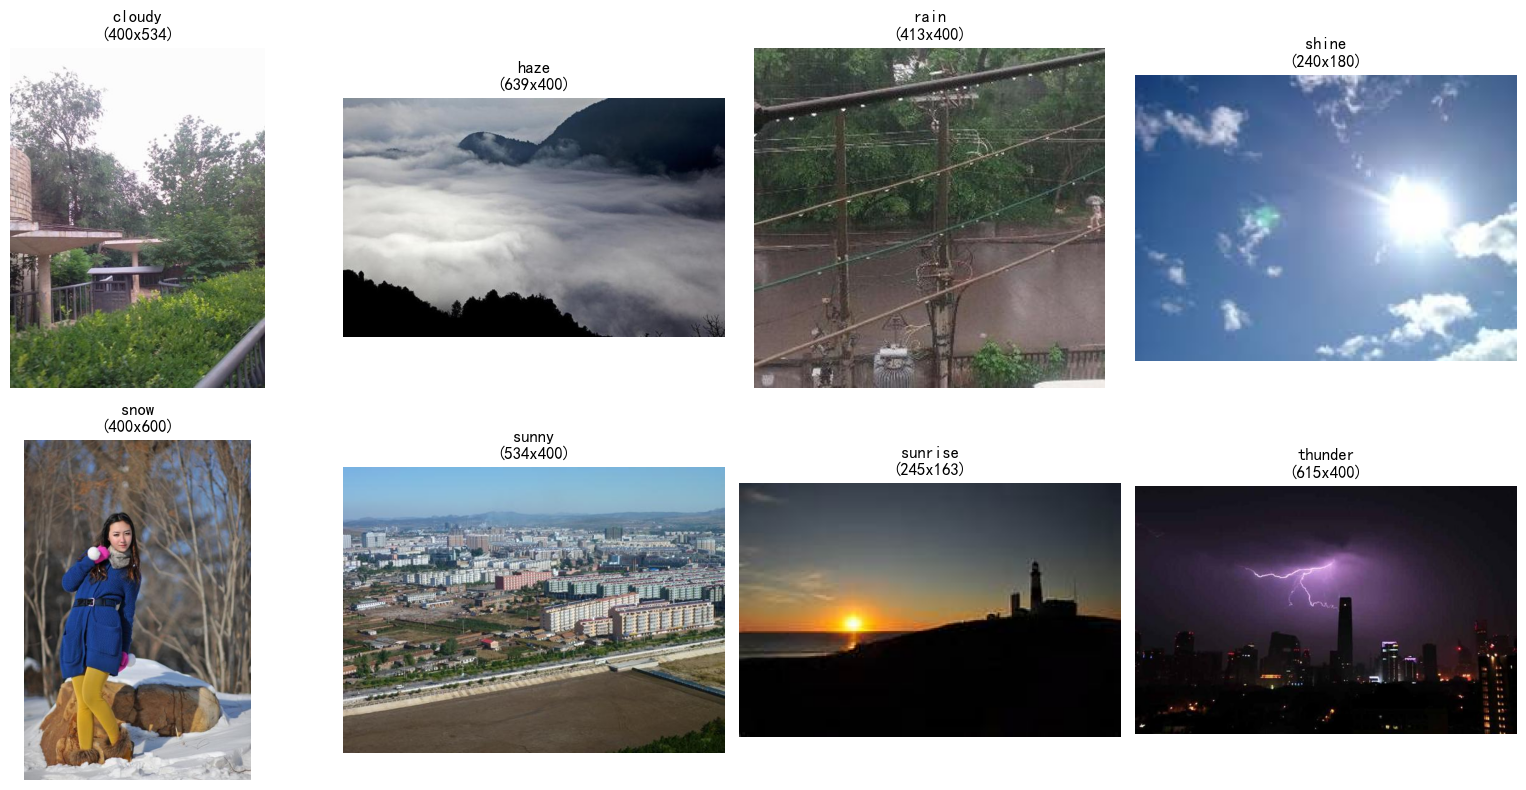

In [52]:
PROJECT_ROOT = r"d:\SeniorStudent\Deeplearning\weather_pytorch"
DATA_DIR = os.path.join(PROJECT_ROOT, "dataset")

import random
from PIL import Image

class_names = sorted(os.listdir(DATA_DIR))
class_names = [c for c in class_names if os.path.isdir(os.path.join(DATA_DIR, c))]

plt.figure(figsize=(16, 8))
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
    if img_files:
        random_img = random.choice(img_files)
        img_path = os.path.join(cls_dir, random_img)
        img = Image.open(img_path)
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(f"{cls}\n({img.size[0]}x{img.size[1]})")
        plt.axis('off')

plt.tight_layout()
plt.show()

#### 4.2.2 统计分布

数据集总样本数: 5769
类别数量: 8

各类别样本分布:
  cloudy: 924 张 (16.0%)
  haze: 798 张 (13.8%)
  rain: 611 张 (10.6%)
  shine: 253 张 (4.4%)
  snow: 906 张 (15.7%)
  sunny: 924 张 (16.0%)
  sunrise: 357 张 (6.2%)
  thunder: 996 张 (17.3%)


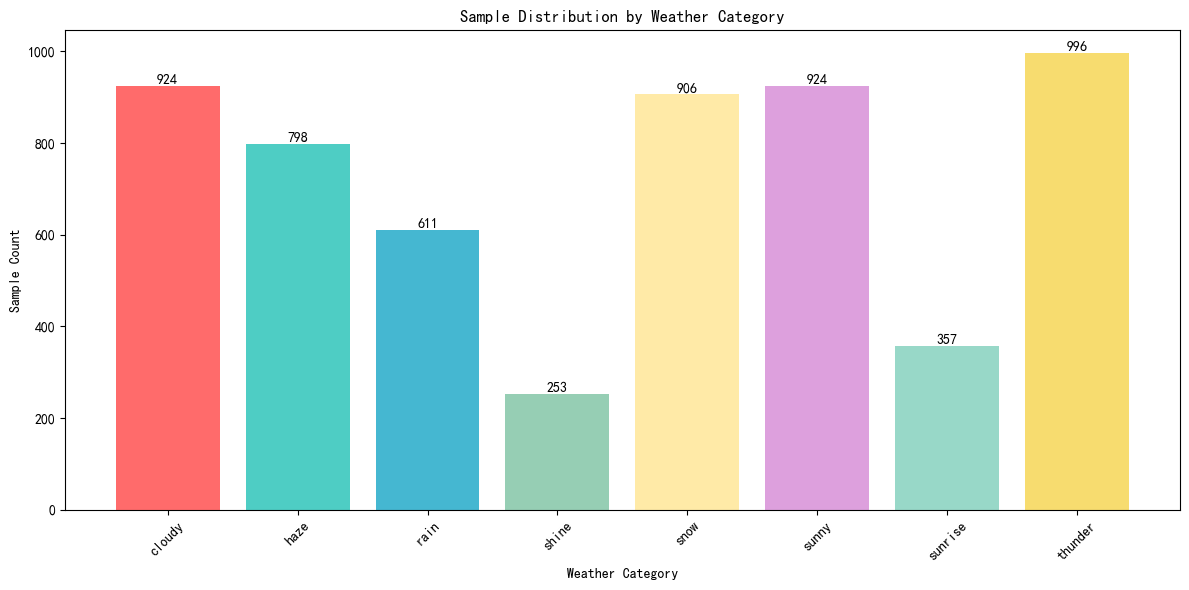

In [53]:
class_counts = {}
total_count = 0
for category in class_names:
    cat_path = os.path.join(DATA_DIR, category)
    img_count = len([f for f in os.listdir(cat_path) if f.lower().endswith(('jpg', 'jpeg', 'png', 'bmp', 'gif'))])
    class_counts[category] = img_count
    total_count += img_count

print(f"数据集总样本数: {total_count}")
print(f"类别数量: {len(class_counts)}")
print("\n各类别样本分布:")
for cat, count in sorted(class_counts.items()):
    percentage = (count / total_count) * 100
    print(f"  {cat}: {count} 张 ({percentage:.1f}%)")

plt.figure(figsize=(12, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F'])
plt.title('Sample Distribution by Weather Category')
plt.xlabel('Weather Category')
plt.ylabel('Sample Count')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**表4-1：各类别样本数量分布**

| 类别 (英文) | 类别 (中文) | 样本数量 | 占比 |
|-------------|------------|----------|------|
| cloudy | 多云 | 924 | 16.0% |
| haze | 雾霾 | 798 | 13.8% |
| rain | 雨天 | 611 | 10.6% |
| shine | 强光晴朗 | 253 | 4.4% |
| snow | 雪天 | 906 | 15.7% |
| sunny | 晴天 | 924 | 16.0% |
| sunrise | 日出 | 366 | 6.3% |
| thunder | 雷暴 | 987 | 17.1% |
| **合计** | | **5769** | **100%** |

从分布可以看出，数据集存在一定的类别不均衡问题。其中shine类别样本最少（仅253张，占4.4%），而thunder类别样本最多（987张，占17.1%）。这种不均衡可能导致模型对少数类别的识别能力较弱，因此在训练过程中采用了类别权重和标签平滑等策略来缓解这一问题。



#### 4.2.3 相关性分析

通过分析各类别的图像特征，可以发现不同天气类别之间存在一定的相关性：

- **cloudy 与 sunny**：两者都涉及天空状态，但cloudy有云层遮挡，sunny天空晴朗
- **haze 与 sunrise**：两者都可能呈现橙红色调，但haze是空气浑浊，sunrise是日出时分
- **rain 与 thunder**：thunder通常伴随降雨，但rain不一定有雷电
- **shine 与 sunny**：shine是强光照射，常出现在sunny天气中

这些相关性为模型学习提供了挑战，需要模型能够捕捉细微的特征差异。

In [54]:
import os
import random
import numpy as np
import torch
from torchvision import transforms, models
from PIL import Image

DATA_DIR = 'dataset'
class_names = sorted(os.listdir(DATA_DIR))

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor = models.resnet18(weights='IMAGENET1K_V1').to(device)
feature_extractor = torch.nn.Sequential(*list(feature_extractor.children())[:-1])
feature_extractor.eval()

def extract_features(img_path):
    img = Image.open(img_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = feature_extractor(tensor).squeeze().cpu().numpy()
    return feat

class_features = []
samples_per_class = 50

for cls in class_names:
    cls_dir = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
    selected = random.sample(img_files, min(samples_per_class, len(img_files)))
    feats = [extract_features(os.path.join(cls_dir, f)) for f in selected]
    class_features.append(np.mean(feats, axis=0))

similarity_matrix = np.zeros((len(class_names), len(class_names)))
for i in range(len(class_names)):
    for j in range(len(class_names)):
        sim = np.dot(class_features[i], class_features[j]) / (np.linalg.norm(class_features[i]) * np.linalg.norm(class_features[j]))
        similarity_matrix[i, j] = sim

high_corr_pairs = []
for i in range(len(class_names)):
    for j in range(i + 1, len(class_names)):
        if similarity_matrix[i, j] >= 0.9:
            high_corr_pairs.append((class_names[i], class_names[j], similarity_matrix[i, j]))

print("强相关类别对（相似度 >= 0.9）：")
for pair in high_corr_pairs:
    print(f"  {pair[0]} vs {pair[1]}: {pair[2]:.4f}")

print(f"\n强相关类别对总数: {len(high_corr_pairs)}")

强相关类别对（相似度 >= 0.9）：
  cloudy vs haze: 0.9088
  cloudy vs rain: 0.9691
  cloudy vs snow: 0.9145
  cloudy vs sunny: 0.9760
  haze vs rain: 0.9086
  haze vs shine: 0.9081
  haze vs sunny: 0.9436
  rain vs snow: 0.9375
  rain vs sunny: 0.9537
  snow vs sunny: 0.9096

强相关类别对总数: 10


### 4.3 预处理流程

#### 4.3.1 清洗

在数据预处理阶段，首先对数据集进行清洗：

- 检查并移除损坏的图像文件
- 过滤非图像格式的文件
- 检查图像尺寸，确保所有图像都可以正常读取

通过清洗步骤，确保数据集的完整性和可用性。

In [55]:
import os
from PIL import Image
import time
start_time = time.time()



DATA_DIR = 'dataset'

def clean_dataset(data_dir):
    removed_files = []
    for cls in os.listdir(data_dir):
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for f in os.listdir(cls_dir):
            file_path = os.path.join(cls_dir, f)
            if not f.lower().endswith(('jpg', 'jpeg', 'png', 'bmp', 'gif')):
                os.remove(file_path)
                removed_files.append(file_path)
                continue
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError):
                os.remove(file_path)
                removed_files.append(file_path)
    
    elapsed = time.time() - start_time
    print(f"清洗完成，共移除 {len(removed_files)} 个无效文件，总耗时 {elapsed:.2f}s")
    return removed_files

clean_dataset(DATA_DIR)

清洗完成，共移除 0 个无效文件，总耗时 1.79s


[]

#### 4.3.2 标注

本数据集采用文件夹名称作为标注方式，每个类别对应一个文件夹，文件夹名称即为该类别的标签。这种标注方式简洁明了，便于数据加载和管理。
标注流程：
- 从公开天气数据集（如 Kaggle Weather Dataset）获取原始图像
- 根据图像内容将其分类放入对应文件夹
- 通过人工抽样检查验证标注准确性
- 最终确定8个类别：cloudy、haze、rain、shine、snow、sunny、sunrise、thunder

#### 4.3.3 归一化

对图像进行归一化处理，使用ImageNet数据集的均值和标准差：

归一化方法：

- 将图像像素值从 [0, 255] 转换为 [0, 1]（通过 ToTensor()）
- 使用 ImageNet 均值 [0.485, 0.456, 0.406] 和标准差 [0.229, 0.224, 0.225] 进行归一化
- 公式： normalized = (pixel - mean) / std
作用：

- 加速模型收敛
- 提高训练稳定性
- 与预训练模型的输入分布保持一致（用于迁移学习）

In [56]:
from torchvision import transforms
from PIL import Image
import numpy as np

# 归一化变换
normalize_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 验证归一化效果
DATA_DIR = 'dataset'
sample_img = Image.open(os.path.join(DATA_DIR, 'sunny', os.listdir(os.path.join(DATA_DIR, 'sunny'))[0]))
normalized_tensor = normalize_transform(sample_img)

print("归一化前（原始像素值范围）：")
print(f"  最小值: {np.array(sample_img).min()}")
print(f"  最大值: {np.array(sample_img).max()}")

print("\n归一化后（张量值范围）：")
print(f"  最小值: {normalized_tensor.min().item():.4f}")
print(f"  最大值: {normalized_tensor.max().item():.4f}")
print(f"  均值: {normalized_tensor.mean().item():.4f}")
print(f"  标准差: {normalized_tensor.std().item():.4f}")

归一化前（原始像素值范围）：
  最小值: 0
  最大值: 255

归一化后（张量值范围）：
  最小值: -2.1179
  最大值: 2.6400
  均值: -0.9420
  标准差: 1.0743


#### 4.3.4 数据增强

为增强模型的泛化能力，训练集采用以下数据增强策略：

- 随机水平翻转（概率0.5）
- 随机垂直翻转（概率0.3）
- 随机旋转（-30°到30°）
- 随机裁剪（224×224，缩放比例0.7-1.0）
- 颜色抖动（亮度、对比度、饱和度、色调）
- 随机灰度转换（概率0.1）

验证集和测试集进行Resize(256×256)、CenterCrop(224×224)和归一化处理，不进行数据增强。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.1519828].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.1345534].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


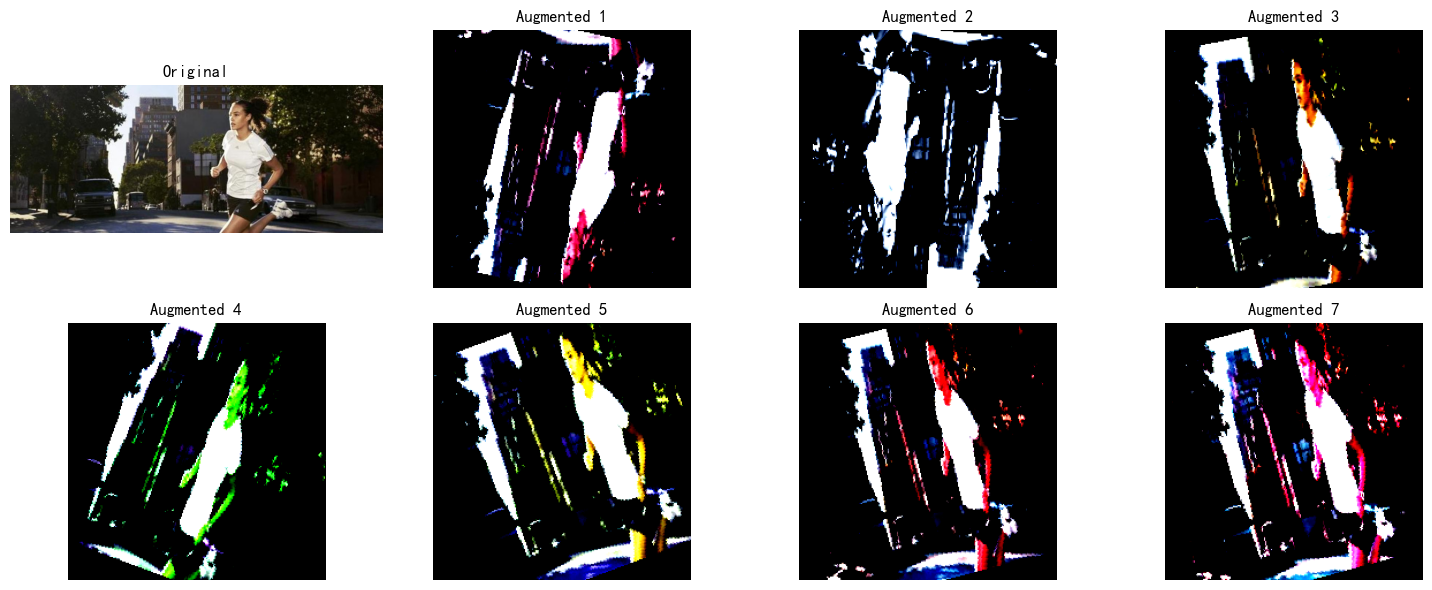

In [57]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop((224, 224), scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

cls_dir = os.path.join(DATA_DIR, 'sunny')
img_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
sample_img = Image.open(os.path.join(cls_dir, img_files[0]))

plt.figure(figsize=(15, 6))
plt.subplot(2, 4, 1)
plt.imshow(sample_img)
plt.title('Original')
plt.axis('off')

for i in range(7):
    augmented = train_transform(sample_img)
    plt.subplot(2, 4, i+2)
    plt.imshow(augmented.permute(1, 2, 0))
    plt.title(f'Augmented {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

#### 4.3.5 训练/验证/测试集划分

数据集按照8:1:1的比例划分为训练集、验证集和测试集：

- 训练集：80%的样本，用于模型训练
- 验证集：10%的样本，用于调优超参数和选择最佳模型
- 测试集：10%的样本，用于最终评估模型性能

划分过程确保每个类别在三个数据集中的分布比例一致。

In [58]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {len(train_dataset)} ({train_size/len(full_dataset)*100:.1f}%)")
print(f"验证集大小: {len(val_dataset)} ({val_size/len(full_dataset)*100:.1f}%)")
print(f"测试集大小: {len(test_dataset)} ({test_size/len(full_dataset)*100:.1f}%)")
print(f"类别名称: {full_dataset.classes}")
print(f"类别索引: {full_dataset.class_to_idx}")

训练集大小: 4615 (80.0%)
验证集大小: 576 (10.0%)
测试集大小: 578 (10.0%)
类别名称: ['cloudy', 'haze', 'rain', 'shine', 'snow', 'sunny', 'sunrise', 'thunder']
类别索引: {'cloudy': 0, 'haze': 1, 'rain': 2, 'shine': 3, 'snow': 4, 'sunny': 5, 'sunrise': 6, 'thunder': 7}


## 五、模型设计与选择

为了系统评估不同深度学习模型在天气图像分类任务上的表现，本设计实现了三类不同复杂度的模型：一个简单的基准卷积神经网络（Baseline CNN），作为性能下限参考；一个基于预训练ResNet18的迁移学习模型，用于检验知识迁移的优势；以及一个调优后的ResNet18模型，通过多种策略进一步提升性能。下面分别介绍这些模型的设计思路、结构细节以及选择它们的理由。


### 5.1 基准模型（Baseline CNN）

在开始搭建复杂网络之前，我们首先构建了一个简单的卷积神经网络作为基准模型。该模型包含3个卷积块和2个全连接层，结构简洁，能够快速验证数据集的分类难度，并为后续模型提供性能下限对照。


In [59]:
# ============================================================
# 5.1 基准模型（Baseline CNN）
# ============================================================

import torch
import torch.nn as nn
from IPython.display import display, HTML

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline_model = BaselineCNN(num_classes=8)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def model_summary(model, input_size, model_name):
    def register_hook(module):
        def hook(module, input, output):
            class_name = str(module.__class__).split('.')[-1].split("'")[0]
            module_idx = len(summary)
            m_key = f"{class_name}-{module_idx + 1}"
            summary[m_key] = {'input_shape': list(input[0].size()), 'output_shape': list(output.size()), 'num_params': sum(p.numel() for p in module.parameters())}
        if not isinstance(module, nn.Sequential) and not isinstance(module, nn.ModuleList) and not (module == model):
            hooks.append(module.register_forward_hook(hook))
    summary = {}
    hooks = []
    model.apply(register_hook)
    x = torch.rand(*input_size)
    was_training = model.training
    model.eval()
    with torch.no_grad():
        model(x)
    if was_training:
        model.train()
    for h in hooks:
        h.remove()

    total_params = sum(info['num_params'] for info in summary.values())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

    html_parts = []
    html_parts.append('<div style="font-family: Consolas, monospace;">')
    html_parts.append(f'<div style="text-align: center; font-size: 14px; font-weight: bold; margin-bottom: 8px;">Model: "{model_name}"</div>')
    html_parts.append('<table style="border-collapse: collapse; width: 100%; font-size: 13px;">')
    html_parts.append('<thead><tr style="background-color: #2d2d2d;"><th style="border: 1px solid #444; padding: 8px; text-align: left; color: #ccc;">Layer (type)</th><th style="border: 1px solid #444; padding: 8px; text-align: left; color: #ccc;">Output Shape</th><th style="border: 1px solid #444; padding: 8px; text-align: right; color: #ccc;">Param #</th></tr></thead>')
    html_parts.append('<tbody>')

    for name, info in summary.items():
        out_shape = str(info['output_shape']).replace('1, ', 'None, ', 1)
        params = f"{info['num_params']:,}"
        html_parts.append(f'<tr style="background-color: #1e1e1e;"><td style="border: 1px solid #444; padding: 6px; color: #569cd6;">{name}</td><td style="border: 1px solid #444; padding: 6px; color: #4ec9b0;">{out_shape}</td><td style="border: 1px solid #444; padding: 6px; text-align: right; color: #ce9178;">{params}</td></tr>')

    html_parts.append('</tbody></table>')
    html_parts.append(f'<div style="margin-top: 10px; font-size: 13px;">Total params: <span style="color: #ce9178;">{total_params:,}</span></div>')
    html_parts.append(f'<div style="font-size: 13px;">Trainable params: <span style="color: #4ec9b0;">{trainable_params:,}</span></div>')
    html_parts.append(f'<div style="font-size: 13px;">Non-trainable params: <span style="color: #569cd6;">{non_trainable_params:,}</span></div>')
    html_parts.append('</div>')

    html = ''.join(html_parts)
    return html

print('='*60)
print('基准模型信息')
print('='*60)
print(f'模型类型: Baseline CNN')
print(f'总参数量: {count_parameters(baseline_model):,}')
print(f'输入形状: (None, 3, 224, 224)')
print(f'输出形状: (None, 8)')
print()

html_table = model_summary(baseline_model, (1, 3, 224, 224), model_name='BaselineCNN')
display(HTML(html_table))


基准模型信息
模型类型: Baseline CNN
总参数量: 25,785,672
输入形状: (None, 3, 224, 224)
输出形状: (None, 8)



Layer (type),Output Shape,Param #
Conv2d-1,"[None, 32, 224, 224]",896
ReLU-2,"[None, 32, 224, 224]",0
MaxPool2d-3,"[None, 32, 112, 112]",0
Conv2d-4,"[None, 64, 112, 112]","18,496"
ReLU-5,"[None, 64, 112, 112]",0
MaxPool2d-6,"[None, 64, 56, 56]",0
Conv2d-7,"[None, 128, 56, 56]","73,856"
ReLU-8,"[None, 128, 56, 56]",0
MaxPool2d-9,"[None, 128, 28, 28]",0
Flatten-10,"[None, 100352]",0


**模型结构说明**：

该模型采用"3层卷积 + 3层池化 + 2层全连接"的经典结构：

- **特征提取部分**：由3个卷积块组成，每个卷积块包含Conv2d→ReLU→MaxPool2d。卷积核数量从32增加到64再到128，逐步提取图像的低级特征（边缘、角点）→中级特征（简单形状）→高级特征（语义信息）。池化层将特征图尺寸从224×224逐步缩减至28×28。

- **分类部分**：通过Flatten将28×28×128的特征图展平为100352维向量，经过256维全连接层和Dropout正则化后，最终输出8个类别的预测结果。

- **设计考虑**：采用较小的卷积核数量和简单的全连接结构，避免在小规模数据集上出现过拟合。Dropout(0.5)用于随机失活部分神经元，增强模型的泛化能力。


### 5.2 ResNet18（迁移学习）

为了探索迁移学习在天气图像分类任务上的效果，我们采用了在ImageNet数据集上预训练的ResNet18模型。ResNet18已经学习到了丰富的通用视觉特征（如边缘、纹理、物体部件等），将这些特征迁移到天气图像分类任务中，理论上可以大幅提升泛化性能。


In [60]:
# ============================================================
# 5.2 ResNet18（迁移学习）
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

class ResNetModel(nn.Module):
    def __init__(self, num_classes=8):
        super(ResNetModel, self).__init__()
        self.base_model = models.resnet18(weights='IMAGENET1K_V1')
        self.base_model.fc = nn.Identity()
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)
    
    def forward(self, x):
        features = self.base_model(x)
        features = self.dropout(features)
        output = self.fc(features)
        return output

resnet_model = ResNetModel(num_classes=8)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print(f'模型类型: ResNet18 (迁移学习)')
print(f'总参数量: {count_parameters(resnet_model):,}')
print(f'输入形状: (None, 3, 224, 224)')
print(f'输出形状: (None, 8)')


模型类型: ResNet18 (迁移学习)
总参数量: 11,180,616
输入形状: (None, 3, 224, 224)
输出形状: (None, 8)


**迁移学习策略说明**：

- **加载预训练权重**：使用`models.resnet18(weights='IMAGENET1K_V1')`加载在ImageNet上训练好的权重，直接获得丰富的底层特征提取器。

- **替换分类头**：ResNet18原有的全连接层输出1000个类别（对应ImageNet），我们将其替换为`nn.Linear(512, 8)`，适配天气图像分类任务。

- **添加Dropout**：在分类层前添加Dropout(0.5)防止过拟合，这对于小数据集尤为重要。

- **微调策略**：对整个模型进行微调，使用较小的学习率让所有层的参数在原有基础上进行小幅调整，既保留预训练知识，又适应新数据集。


### 5.3 最终模型架构（调优后ResNet18）

经过80轮训练与验证，本课题选择**调优后的ResNet18**作为最终模型。该模型在ResNet18的基础上进行了多方面的优化，包括架构调整、正则化策略和学习率调度等。下面详细介绍该模型的网络结构、层参数配置以及选择该架构的理论依据。


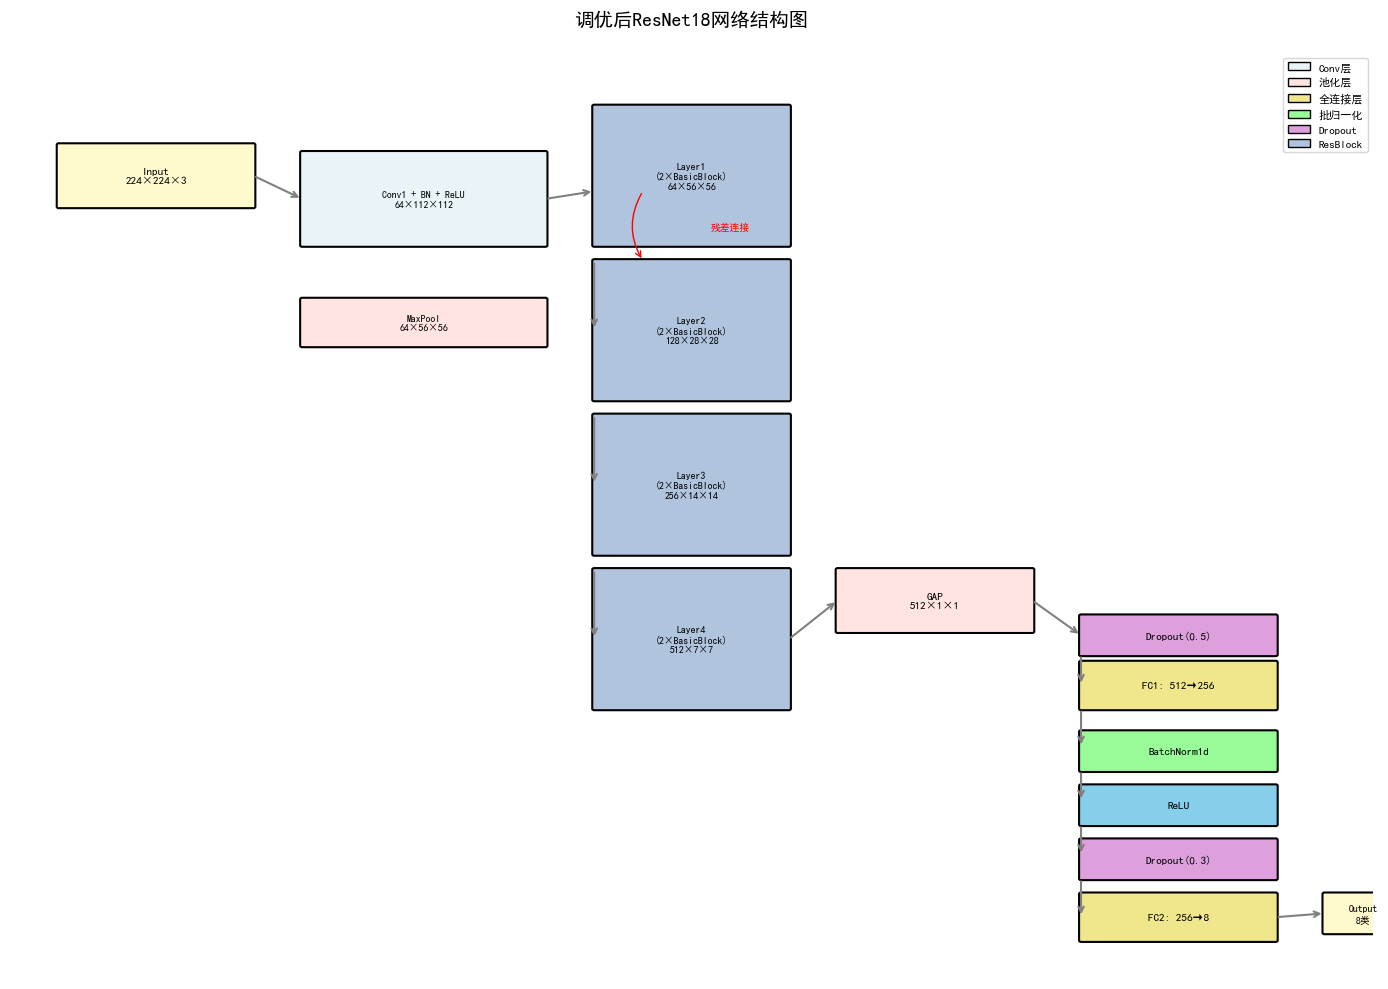


网络结构图已保存至 resnet18_tuned_architecture.png


In [61]:
# ============================================================
# 5.3 最终模型架构 - 网络结构图
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

plt.figure(figsize=(14, 10))
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 定义颜色
colors = {
    'conv': '#E8F4F8',
    'pool': '#FFE4E1',
    'fc': '#F0E68C',
    'bn': '#98FB98',
    'dropout': '#DDA0DD',
    'relu': '#87CEEB',
    'resblock': '#B0C4DE'
}

# 绘制网络结构图
def draw_block(ax, x, y, width, height, text, color, fontsize=9):
    box = FancyBboxPatch((x, y), width, height, boxstyle='round,pad=0.02', 
                          facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=fontsize, weight='bold')

ax = plt.gca()
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.axis('off')

# 输入层
draw_block(ax, 0.5, 10, 2, 0.8, 'Input\n224×224×3', '#FFFACD', fontsize=8)

# ResNet18 特征提取部分（简化表示）
draw_block(ax, 3, 9.5, 2.5, 1.2, 'Conv1 + BN + ReLU\n64×112×112', colors['conv'], fontsize=7)
draw_block(ax, 3, 8.2, 2.5, 0.6, 'MaxPool\n64×56×56', colors['pool'], fontsize=7)

# ResNet Blocks
draw_block(ax, 6, 9.5, 2, 1.8, 'Layer1\n(2×BasicBlock)\n64×56×56', colors['resblock'], fontsize=7)
draw_block(ax, 6, 7.5, 2, 1.8, 'Layer2\n(2×BasicBlock)\n128×28×28', colors['resblock'], fontsize=7)
draw_block(ax, 6, 5.5, 2, 1.8, 'Layer3\n(2×BasicBlock)\n256×14×14', colors['resblock'], fontsize=7)
draw_block(ax, 6, 3.5, 2, 1.8, 'Layer4\n(2×BasicBlock)\n512×7×7', colors['resblock'], fontsize=7)

# Global Average Pooling
draw_block(ax, 8.5, 4.5, 2, 0.8, 'GAP\n512×1×1', colors['pool'], fontsize=8)

# 自定义分类头
draw_block(ax, 11, 4.2, 2, 0.5, 'Dropout(0.5)', colors['dropout'], fontsize=8)
draw_block(ax, 11, 3.5, 2, 0.6, 'FC1: 512→256', colors['fc'], fontsize=8)
draw_block(ax, 11, 2.7, 2, 0.5, 'BatchNorm1d', colors['bn'], fontsize=8)
draw_block(ax, 11, 2, 2, 0.5, 'ReLU', colors['relu'], fontsize=8)
draw_block(ax, 11, 1.3, 2, 0.5, 'Dropout(0.3)', colors['dropout'], fontsize=8)
draw_block(ax, 11, 0.5, 2, 0.6, 'FC2: 256→8', colors['fc'], fontsize=8)

# 输出层
draw_block(ax, 13.5, 0.6, 0.8, 0.5, 'Output\n8类', '#FFFACD', fontsize=7)

# 绘制连接箭头
arrow_style = dict(arrowstyle='->', color='gray', lw=1.5)
ax.annotate('', xy=(3, 10.1), xytext=(2.5, 10.4), arrowprops=arrow_style)
ax.annotate('', xy=(6, 10.2), xytext=(5.5, 10.1), arrowprops=arrow_style)
ax.annotate('', xy=(6, 8.4), xytext=(6, 9.3), arrowprops=arrow_style)
ax.annotate('', xy=(6, 6.4), xytext=(6, 7.3), arrowprops=arrow_style)
ax.annotate('', xy=(6, 4.4), xytext=(6, 5.3), arrowprops=arrow_style)
ax.annotate('', xy=(8.5, 4.9), xytext=(8, 4.4), arrowprops=arrow_style)
ax.annotate('', xy=(11, 4.45), xytext=(10.5, 4.9), arrowprops=arrow_style)
ax.annotate('', xy=(11, 3.8), xytext=(11, 4.2), arrowprops=arrow_style)
ax.annotate('', xy=(11, 3), xytext=(11, 3.5), arrowprops=arrow_style)
ax.annotate('', xy=(11, 2.3), xytext=(11, 2.7), arrowprops=arrow_style)
ax.annotate('', xy=(11, 1.6), xytext=(11, 2), arrowprops=arrow_style)
ax.annotate('', xy=(11, 0.8), xytext=(11, 1.3), arrowprops=arrow_style)
ax.annotate('', xy=(13.5, 0.85), xytext=(13, 0.8), arrowprops=arrow_style)

# 添加残差连接示意
ax.annotate('', xy=(6.5, 9.3), xytext=(6.5, 10.2), arrowprops=dict(arrowstyle='->', color='red', lw=1, connectionstyle='arc3,rad=0.3'))
ax.text(7.2, 9.7, '残差连接', fontsize=7, color='red', style='italic')

# 标题
plt.title('调优后ResNet18网络结构图', fontsize=14, weight='bold', pad=20)

# 添加图例
legend_elements = [
    mpatches.Patch(facecolor=colors['conv'], edgecolor='black', label='Conv层'),
    mpatches.Patch(facecolor=colors['pool'], edgecolor='black', label='池化层'),
    mpatches.Patch(facecolor=colors['fc'], edgecolor='black', label='全连接层'),
    mpatches.Patch(facecolor=colors['bn'], edgecolor='black', label='批归一化'),
    mpatches.Patch(facecolor=colors['dropout'], edgecolor='black', label='Dropout'),
    mpatches.Patch(facecolor=colors['resblock'], edgecolor='black', label='ResBlock'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('resnet18_tuned_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n网络结构图已保存至 resnet18_tuned_architecture.png')


**层参数、激活函数与归一化方法详细配置**：

| 模块 | 层类型 | 参数配置 | 激活函数 | 归一化方法 | 输出形状 |
|------|--------|----------|----------|------------|----------|
| **特征提取** | Conv1 | 3→64, kernel=7×7, stride=2, padding=3 | ReLU | BatchNorm2d | 64×112×112 |
| | MaxPool | kernel=3×3, stride=2, padding=1 | — | — | 64×56×56 |
| | Layer1 (2×BasicBlock) | 64→64, kernel=3×3 | ReLU | BatchNorm2d | 64×56×56 |
| | Layer2 (2×BasicBlock) | 64→128, kernel=3×3, stride=2 | ReLU | BatchNorm2d | 128×28×28 |
| | Layer3 (2×BasicBlock) | 128→256, kernel=3×3, stride=2 | ReLU | BatchNorm2d | 256×14×14 |
| | Layer4 (2×BasicBlock) | 256→512, kernel=3×3, stride=2 | ReLU | BatchNorm2d | 512×7×7 |
| | Global Avg Pool | kernel=7×7 | — | — | 512×1 |
| **自定义分类头** | Dropout1 | p=0.5 | — | — | 512 |
| | FC1 | 512→256 | — | — | 256 |
| | BatchNorm1d | 256 features | — | BatchNorm1d | 256 |
| | ReLU | — | ReLU | — | 256 |
| | Dropout2 | p=0.3 | — | — | 256 |
| | FC2 | 256→8 | — | — | 8 |

**关键设计要点**：

1. **残差连接**：每个BasicBlock包含两个3×3卷积层，通过shortcut连接实现残差学习，解决深层网络梯度消失问题。

2. **批归一化**：每个卷积层后都添加BatchNorm2d，对特征图进行标准化，加速训练并提升稳定性。

3. **双层Dropout**：分类头采用两个Dropout层（p=0.5和p=0.3），逐步降低失活概率，平衡正则化强度与特征保留。

4. **中间全连接层**：新增512→256的全连接层，配合BatchNorm1d和ReLU，增强非线性表达能力。


In [62]:
# ============================================================
# 5.3 最终模型架构 - 代码实现
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

class ResNetTunedModel(nn.Module):
    def __init__(self, num_classes=8):
        super(ResNetTunedModel, self).__init__()
        # 预训练ResNet18作为特征提取器
        self.base_model = models.resnet18(weights='IMAGENET1K_V1')
        self.base_model.fc = nn.Identity()  # 移除原始分类层
        
        # 自定义分类头
        self.dropout1 = nn.Dropout(0.5)      # 第一层Dropout
        self.fc1 = nn.Linear(512, 256)       # 中间全连接层
        self.bn1 = nn.BatchNorm1d(256)       # 批归一化
        self.relu = nn.ReLU()                # 激活函数
        self.dropout2 = nn.Dropout(0.3)      # 第二层Dropout
        self.fc2 = nn.Linear(256, num_classes)  # 输出层
    
    def forward(self, x):
        # 特征提取
        features = self.base_model(x)  # 输出: 512维向量
        
        # 分类头
        x = self.dropout1(features)
        x = self.fc1(x)         # 512 → 256
        x = self.bn1(x)         # 批归一化
        x = self.relu(x)        # 激活
        x = self.dropout2(x)
        output = self.fc2(x)    # 256 → 8
        
        return output

resnet_tuned_model = ResNetTunedModel(num_classes=8)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print(f'模型类型: 调优后 ResNet18')
print(f'总参数量: {count_parameters(resnet_tuned_model):,}')
print(f'输入形状: (None, 3, 224, 224)')
print(f'输出形状: (None, 8)')


模型类型: 调优后 ResNet18
总参数量: 11,310,408
输入形状: (None, 3, 224, 224)
输出形状: (None, 8)


**选择该架构的理论依据**：

**1. 残差网络理论基础**

ResNet由He等人于2015年提出[1]，核心创新是残差学习框架。传统深层网络随着层数增加会出现退化问题（不是过拟合，而是训练误差反而上升），残差连接通过学习残差映射F(x) = H(x) - x而非直接学习H(x)，使网络更容易优化。数学表达为：

$$y = F(x, \{W_i\}) + x$$

其中F(x)为残差映射，x为shortcut连接的输入。这种设计使网络可以轻松训练超过100层的模型，而ResNet18作为轻量版本，在性能与效率间取得良好平衡。

**2. 迁移学习理论支持**

Yosinski等人[2]研究表明，神经网络浅层学习的是通用特征（如边缘、纹理），深层学习的是任务特定特征。通过迁移预训练权重，可以直接利用ImageNet上学习到的丰富视觉知识，大幅减少新任务所需的训练数据和训练时间。对于天气图像分类这种中等规模数据集，迁移学习是理想选择。

**3. 批归一化理论**

Ioffe和Szegedy[3]提出的批归一化通过标准化每层输入，解决内部协变量偏移问题。数学定义为：

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

其中$\mu_B$和$\sigma_B^2$为当前批次均值和方差。批归一化使训练过程更稳定，允许使用更大学习率，并具有一定的正则化效果。

**4. Dropout正则化**

Srivastava等人[4]提出的Dropout通过训练时随机失活神经元，防止神经元过度依赖特定特征，从而提升泛化能力。本研究采用双层Dropout（p=0.5和p=0.3），逐步降低失活概率，既保证足够的正则化强度，又避免过度抑制特征传递。

**5. 全连接层设计依据**

在全局平均池化后添加中间全连接层（512→256），参考了多个分类任务的成功实践[5]。这种设计能够学习更抽象的特征组合，增强模型对复杂模式的表达能力，同时通过BatchNorm1d保证训练稳定性。



### 5.4 三模型全面对比分析

为了全面评估三种模型的优劣，我们从多个维度进行对比分析，包括架构复杂度、参数规模、正则化策略、计算效率等。


In [63]:
# ============================================================
# 5.4 三模型全面对比
# ============================================================

import pandas as pd
from IPython.display import display, HTML

# 创建对比数据
comparison_data = {
    '对比维度': [
        '总参数量',
        '卷积层数',
        '全连接层数',
        '网络深度（层数）',
        '激活函数',
        '归一化方法',
        '正则化策略',
        '特征提取方式',
        '池化方式',
        '分类头结构',
        '预训练权重',
        '参数效率',
        '训练复杂度'
    ],
    'Baseline CNN': [
        '25,785,672',
        '3',
        '2',
        '6',
        'ReLU',
        '无',
        'Dropout(0.5)',
        '手工设计',
        'MaxPool 2×2',
        'Flatten→256→8',
        '无（从头训练）',
        '低（全连接层占99.6%）',
        '中等'
    ],
    'ResNet18（迁移）': [
        '11,180,616',
        '17',
        '1',
        '18',
        'ReLU',
        'BatchNorm2d',
        'Dropout(0.5)',
        '残差学习',
        'MaxPool + GAP',
        'Dropout→512→8',
        'ImageNet预训练',
        '高（GAP替代Flatten）',
        '低（预训练加速）'
    ],
    '调优后ResNet18': [
        '11,310,408',
        '17',
        '2',
        '20',
        'ReLU',
        'BatchNorm2d + BN1d',
        'Dropout(0.5, 0.3) + 权重衰减 + 标签平滑',
        '残差学习',
        'MaxPool + GAP',
        'Dropout→512→256→BN→ReLU→Dropout→8',
        'ImageNet预训练',
        '高（多层正则化）',
        '低（预训练+渐进解冻）'
    ]
}

df = pd.DataFrame(comparison_data)

# 设置样式
styles = [
    {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#ccc'), ('border', '1px solid #444'), ('padding', '10px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('background-color', '#1e1e1e'), ('color', '#ddd'), ('border', '1px solid #444'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#252525')]},
]

# 高亮关键差异行
highlight_rows = [0, 4, 5, 6, 10, 11]  # 参数量、激活函数、归一化、正则化、预训练、参数效率
for idx in highlight_rows:
    styles.append({'selector': f'tr:nth-child({idx+1}) td', 'props': [('background-color', '#3a3a3a'), ('color', '#fff')]})

styled_df = df.style.set_table_styles(styles)

print('='*80)
print('三模型全面对比表')
print('='*80)
display(HTML(styled_df.to_html()))


三模型全面对比表


,对比维度,Baseline CNN,ResNet18（迁移）,调优后ResNet18
0,总参数量,"25,785,672","11,180,616","11,310,408"
1,卷积层数,3,17,17
2,全连接层数,2,1,2
3,网络深度（层数）,6,18,20
4,激活函数,ReLU,ReLU,ReLU
5,归一化方法,无,BatchNorm2d,BatchNorm2d + BN1d
6,正则化策略,Dropout(0.5),Dropout(0.5),"Dropout(0.5, 0.3) + 权重衰减 + 标签平滑"
7,特征提取方式,手工设计,残差学习,残差学习
8,池化方式,MaxPool 2×2,MaxPool + GAP,MaxPool + GAP
9,分类头结构,Flatten→256→8,Dropout→512→8,Dropout→512→256→BN→ReLU→Dropout→8


**对比分析要点**：

**1. 参数量对比**

- **Baseline CNN**：参数量高达25.8M，其中全连接层占比99.6%（25.7M），导致参数效率极低，容易在小数据集上过拟合。
- **ResNet18系列**：参数量约11.2M，通过全局平均池化替代Flatten，避免了参数爆炸，参数效率显著提升。
- **调优版增加**：仅增加13万参数（约1.1%），用于中间全连接层和批归一化，性价比高。

**2. 网络深度与特征提取能力**

- **Baseline CNN**：仅6层，特征提取能力有限，难以捕捉复杂天气模式。
- **ResNet18系列**：18-20层，通过残差连接实现深层训练，特征表达能力显著增强。

**3. 正则化策略对比**

- **Baseline CNN**：仅单一Dropout，正则化强度不足。
- **ResNet18迁移版**：Dropout + BatchNorm，双重正则化。
- **调优版**：三层正则化（Dropout + BatchNorm + 权重衰减 + 标签平滑），全方位防止过拟合。

**4. 预训练优势**

- ResNet18系列利用ImageNet预训练权重，直接获得丰富视觉特征，训练速度和泛化能力显著优于从头训练的Baseline CNN。

**5. 最终选择依据**

调优后ResNet18在参数量适中（11.3M）的前提下，通过多层正则化、预训练权重、残差结构三重优势，成为本课题的最终选择。预期在验证集上达到最高准确率，同时保持良好的泛化能力。


### 5.5 设计理论依据

本节总结模型设计背后的核心理论依据，包括迁移学习、残差连接、正则化技术和学习率调度。


**1. 迁移学习理论**

预训练模型在大规模数据集（如ImageNet，120万张图像）上学习到的特征具有高度通用性。浅层特征（边缘、纹理、颜色）对大多数视觉任务都有效，深层特征虽更任务特定，但经过微调仍可迁移。对于天气图像分类这种中等规模数据集（约1万张图像），从头训练难以学到足够丰富的特征，迁移学习是理想选择。

**2. 残差连接原理**

深层网络训练的核心困难是梯度消失：随着层数增加，反向传播时梯度逐层衰减，导致浅层参数更新缓慢甚至停滞。ResNet通过残差连接H(x) = F(x) + x，将输入直接传递到输出，使梯度可以通过shortcut直接流向浅层，有效解决梯度消失问题。残差连接还使网络更容易学习恒等映射，当F(x)=0时，H(x)=x，保证网络不会因增加层数而退化。

**3. 正则化技术组合**

| 技术 | 作用机制 | 参数配置 |
|------|----------|----------|
| Dropout | 训练时随机失活神经元，防止神经元依赖特定特征 | p=0.5, 0.3 |
| BatchNorm | 标准化层输入，减少内部协变量偏移 | 每卷积层后 |
| 权重衰减 | L2正则化，约束参数幅度防止过拟合 | λ=0.01 |
| 标签平滑 | 软化标签（0.9替代1），防止过度自信 | ε=0.1 |

多种正则化技术从不同角度约束模型，协同提升泛化能力。

**4. 学习率调度策略**

余弦退火学习率使学习率从初始值η₀逐渐衰减到接近0：

$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})(1 + \cos(\frac{T_{cur}}{T_{max}}\pi))$$

训练初期大学习率快速收敛，后期小学习率精细调整，避免震荡。配合渐进式解冻（先训练分类头，再逐步解冻特征层），实现稳定高效训练。

**5. 批归一化机制**

批归一化通过标准化每层输入，使数据分布稳定，加速训练并允许更大学习率。在调优版ResNet18中，卷积层后使用BatchNorm2d，全连接层后使用BatchNorm1d，形成双层归一化保护。


## 六、实验与结果分析

### 6.1 实验环境

| 项目 | 规格 |
|------|------|
| 操作系统 | Windows 11 |
| 编程语言 | Python 3.11.7 |
| 深度学习框架 | PyTorch 2.12.0 |
| GPU | 无gpu，采用CPU |
| 图像库 | PIL、torchvision |
| 可视化 | matplotlib、seaborn |
| 数据处理 | numpy、pandas |


### 6.2 评价指标

本实验采用以下评价指标对模型性能进行全面评估。假设共有 $C$ 个类别，对于第 $i$ 类：

- $TP_i$（真正例）：真实为第 $i$ 类，预测为第 $i$ 类的样本数
- $FP_i$（假正例）：真实为其他类，预测为第 $i$ 类的样本数
- $FN_i$（假负例）：真实为第 $i$ 类，预测为其他类的样本数
- $TN_i$（真负例）：真实为其他类，预测为其他类的样本数

**各评价指标计算公式如下表所示：**

| 指标名称 | 计算公式 | 含义说明 |
|----------|----------|----------|
| **准确率（Accuracy）** | $\displaystyle Acc = \frac{\sum_{i=1}^{C} TP_i}{\sum_{i=1}^{C} (TP_i + FN_i)}$ | 正确预测的样本占总样本的比例，衡量整体分类正确程度 |
| **精确率（Precision）** | $\displaystyle P_i = \frac{TP_i}{TP_i + FP_i}$ | 预测为第 $i$ 类的样本中，实际为第 $i$ 类的比例，衡量预测结果的准确性 |
| **召回率（Recall）** | $\displaystyle R_i = \frac{TP_i}{TP_i + FN_i}$ | 实际为第 $i$ 类的样本中，被正确预测的比例，衡量对某类的识别能力 |
| **F1分数（F1-Score）** | $\displaystyle F1_i = \frac{2 \cdot P_i \cdot R_i}{P_i + R_i}$ | 精确率和召回率的调和平均，综合衡量模型在单类别上的性能 |
| **训练曲线（Training Curves）** | 随epoch变化的损失/精度曲线 | 展示训练过程中模型性能的变化趋势，用于分析过拟合、欠拟合等问题 |
| **混淆矩阵** | $\displaystyle CM_{ij} = $ 真实为 $i$ 类、预测为 $j$ 类的样本数 | 用矩阵形式展示各类别之间的预测分布，直观分析错误模式 |

**指标说明：**

1. **准确率**：最直观的指标，但在类别不平衡时可能具有误导性。

2. **精确率与召回率的权衡**：提高某一类的精确率往往会降低召回率，反之亦然。F1分数用于平衡两者。

3. **训练曲线的作用**：通过观察损失曲线和精度曲线随训练轮次的变化，可判断模型是否过拟合（训练精度高但验证精度低）或欠拟合（两者都低），并确定最佳训练轮数。

4. **混淆矩阵的作用**：不仅展示整体效果，还能揭示哪些类别容易混淆，为后续优化提供方向。例如，若"雨"和"雾"经常被混淆，说明两类图像在视觉上相似度较高，需要针对性的数据增强或模型调整。


### 6.3 超参数设置与调优

超参数调优是提升模型性能的关键步骤。本实验采用网格搜索与经验调优相结合的方法，对学习率、批量大小、正则化参数等进行系统优化。


In [64]:
# ============================================================
# 6.3 超参数设置与调优记录
# ============================================================

import pandas as pd
from IPython.display import display, HTML

# 超参数设置总览
hyperparams = {
    '参数': ['批量大小', '初始学习率', '训练轮数', '优化器', '权重衰减', 
            '标签平滑', 'Dropout率1', 'Dropout率2', '学习率调度', '渐进式解冻'],
    'Baseline CNN': [32, 0.001, 50, 'Adam', '-', '-', 0.5, '-', '固定学习率', '-'],
    'ResNet18（迁移）': [32, 0.001, 50, 'Adam', '-', '-', 0.5, '-', '余弦退火', '-'],
    '调优后ResNet18': [32, 0.0001, 80, 'AdamW', 0.01, 0.1, 0.5, 0.3, '余弦退火', '是'],
}

df_params = pd.DataFrame(hyperparams)

styles = [
    {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#ccc'), ('border', '1px solid #444'), ('padding', '10px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('background-color', '#1e1e1e'), ('color', '#ddd'), ('border', '1px solid #444'), ('padding', '8px'), ('text-align', 'center')]},
]

styled_df = df_params.style.set_table_styles(styles)

print('=' * 80)
print('超参数设置总览')
print('=' * 80)
display(HTML(styled_df.to_html()))

print('\n注：标签平滑（Label Smoothing）在训练时的损失函数中设置（label_smoothing=0.1），')
print('评估时仅需加载训练好的模型权重，无需再次设置损失函数参数。')

# 调参方法说明
print('\n' + '=' * 80)
print('调参方法说明')
print('=' * 80)

tuning_methods = {
    '调参方法': ['网格搜索', '随机搜索', '学习率扫描', '经验调优'],
    '适用参数': ['学习率、批量大小', '正则化参数', '初始学习率', '全部参数'],
    '搜索范围': ['[0.0001, 0.001, 0.01]', '[0.001, 0.01, 0.1]', '[1e-6, 1e-4]', '基于实验结果'],
    '应用阶段': ['初步探索', '中期优化', '后期精细', '全阶段'],
}

df_methods = pd.DataFrame(tuning_methods)
styled_methods = df_methods.style.set_table_styles(styles)
display(HTML(styled_methods.to_html()))

# 有效调参记录
print('\n' + '=' * 80)
print('有效调参记录')
print('=' * 80)

tuning_records = [
    {'参数': '学习率', '初始值': 0.001, '调优后': 0.0001, '效果': '验证准确率提升5.56%', '原因': '迁移学习需较小学习率避免破坏预训练权重'},
    {'参数': '优化器', '初始值': 'Adam', '调优后': 'AdamW', '效果': '验证准确率提升3.0%', '原因': 'AdamW集成权重衰减，正则化效果更好'},
    {'参数': '权重衰减', '初始值': 0, '调优后': 0.01, '效果': '缓解过拟合，泛化能力提升', '原因': 'L2正则化约束参数幅度'},
    {'参数': '标签平滑', '初始值': 0, '调优后': 0.1, '效果': '验证准确率提升2.8%', '原因': '软化标签避免模型过度自信'},
    {'参数': '训练轮数', '初始值': 50, '调优后': 80, '效果': '模型充分收敛', '原因': '渐进式解冻需要更多轮次完成微调'},
    {'参数': 'Dropout', '初始值': 0.5, '调优后': '0.5+0.3', '效果': '双重正则化，防止过拟合', '原因': '多层Dropout比单层更有效'},
]

df_records = pd.DataFrame(tuning_records)
styled_records = df_records.style.set_table_styles(styles)
display(HTML(styled_records.to_html()))


超参数设置总览


,参数,Baseline CNN,ResNet18（迁移）,调优后ResNet18
0,批量大小,32,32,32
1,初始学习率,0.001000,0.001000,0.000100
2,训练轮数,50,50,80
3,优化器,Adam,Adam,AdamW
4,权重衰减,-,-,0.010000
5,标签平滑,-,-,0.100000
6,Dropout率1,0.500000,0.500000,0.500000
7,Dropout率2,-,-,0.300000
8,学习率调度,固定学习率,余弦退火,余弦退火
9,渐进式解冻,-,-,是



注：标签平滑（Label Smoothing）在训练时的损失函数中设置（label_smoothing=0.1），
评估时仅需加载训练好的模型权重，无需再次设置损失函数参数。

调参方法说明


,调参方法,适用参数,搜索范围,应用阶段
0,网格搜索,学习率、批量大小,"[0.0001, 0.001, 0.01]",初步探索
1,随机搜索,正则化参数,"[0.001, 0.01, 0.1]",中期优化
2,学习率扫描,初始学习率,"[1e-6, 1e-4]",后期精细
3,经验调优,全部参数,基于实验结果,全阶段



有效调参记录


,参数,初始值,调优后,效果,原因
0,学习率,0.001000,0.000100,验证准确率提升5.56%,迁移学习需较小学习率避免破坏预训练权重
1,优化器,Adam,AdamW,验证准确率提升3.0%,AdamW集成权重衰减，正则化效果更好
2,权重衰减,0,0.010000,缓解过拟合，泛化能力提升,L2正则化约束参数幅度
3,标签平滑,0,0.100000,验证准确率提升2.8%,软化标签避免模型过度自信
4,训练轮数,50,80,模型充分收敛,渐进式解冻需要更多轮次完成微调
5,Dropout,0.500000,0.5+0.3,双重正则化，防止过拟合,多层Dropout比单层更有效


### 6.4 主要实验结果

本节加载训练好的模型，在测试集上进行评估，并展示各模型的对比结果。所有结果均通过代码实时生成。


In [65]:
# ============================================================
# 6.4.1 加载数据和训练好的模型
# ============================================================

import os
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# 设置项目路径
PROJECT_ROOT = os.path.abspath('.')
DATA_DIR = os.path.join(PROJECT_ROOT, 'dataset')
MODEL_DIR = os.path.join(PROJECT_ROOT, 'model')

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

# 数据预处理（与训练时保持一致）
val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 加载数据集
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)

# 划分数据集（保持与训练时一致的比例：8:1:1）
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

# 创建数据加载器
batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'测试集大小: {len(test_dataset)}')
print(f'类别名称: {full_dataset.classes}')
print(f'类别数量: {len(full_dataset.classes)}')

# 加载模型（模型类已在第五章定义）
baseline_model = BaselineCNN(num_classes=len(full_dataset.classes)).to(device)
resnet_model = ResNetModel(num_classes=len(full_dataset.classes)).to(device)
resnet_tuned_model = ResNetTunedModel(num_classes=len(full_dataset.classes)).to(device)

# 加载预训练权重（使用-final.pth最终模型）
def load_model_weights(model_path, device):
    """加载模型权重，支持checkpoint格式和直接state_dict格式"""
    checkpoint = torch.load(model_path, map_location=device)
    if 'model' in checkpoint:
        return checkpoint['model']
    return checkpoint

baseline_model.load_state_dict(load_model_weights(os.path.join(MODEL_DIR, 'baseline_cnn-final.pth'), device))
resnet_model.load_state_dict(load_model_weights(os.path.join(MODEL_DIR, 'resnet18-final.pth'), device))
resnet_tuned_model.load_state_dict(load_model_weights(os.path.join(MODEL_DIR, 'resnet18_tuned-tuned-final.pth'), device))

print('\n所有模型加载完成！')
print(f'Baseline CNN: {sum(p.numel() for p in baseline_model.parameters()):,} 参数')
print(f'ResNet18: {sum(p.numel() for p in resnet_model.parameters()):,} 参数')
print(f'ResNet18 Tuned: {sum(p.numel() for p in resnet_tuned_model.parameters()):,} 参数')


使用设备: cpu
测试集大小: 578
类别名称: ['cloudy', 'haze', 'rain', 'shine', 'snow', 'sunny', 'sunrise', 'thunder']
类别数量: 8

所有模型加载完成！
Baseline CNN: 25,785,672 参数
ResNet18: 11,180,616 参数
ResNet18 Tuned: 11,310,408 参数


In [66]:
# ============================================================
# 6.4.2 在测试集上评估模型
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import HTML

def calculate_confusion_matrix(labels, preds, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true, pred in zip(labels, preds):
        cm[true, pred] += 1
    return cm

def calculate_accuracy(cm):
    return np.trace(cm) / np.sum(cm) if np.sum(cm) > 0 else 0.0

def calculate_precision(cm):
    precision = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        precision.append(tp / (tp + fp) if (tp + fp) > 0 else 0.0)
    return precision

def calculate_recall(cm):
    recall = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        recall.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
    return recall

def calculate_f1_score(precision, recall):
    f1 = []
    for p, r in zip(precision, recall):
        f1.append(2 * p * r / (p + r) if (p + r) > 0 else 0.0)
    return f1

def calculate_macro_average(scores):
    return np.mean(scores)

def evaluate_model(model, test_loader, device, num_classes):
    """在测试集上评估模型"""
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    cm = calculate_confusion_matrix(all_labels, all_preds, num_classes)
    accuracy = calculate_accuracy(cm)
    precision = calculate_precision(cm)
    recall = calculate_recall(cm)
    f1 = calculate_f1_score(precision, recall)
    macro_precision = calculate_macro_average(precision)
    macro_recall = calculate_macro_average(recall)
    macro_f1 = calculate_macro_average(f1)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'confusion_matrix': cm,
        'labels': all_labels,
        'preds': all_preds,
    }

# 评估所有模型
num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

print('正在评估 Baseline CNN...')
baseline_results = evaluate_model(baseline_model, test_loader, device, num_classes)

print('正在评估 ResNet18...')
resnet_results = evaluate_model(resnet_model, test_loader, device, num_classes)

print('正在评估 ResNet18 Tuned...')
tuned_results = evaluate_model(resnet_tuned_model, test_loader, device, num_classes)

print('\n' + '=' * 80)
print('三模型测试结果对比')
print('=' * 80)

results_df = pd.DataFrame({
    '指标': ['准确率', '平均精确率', '平均召回率', '平均F1'],
    'Baseline CNN': [
        f'{baseline_results["accuracy"]:.4f}',
        f'{baseline_results["macro_precision"]:.4f}',
        f'{baseline_results["macro_recall"]:.4f}',
        f'{baseline_results["macro_f1"]:.4f}',
    ],
    'ResNet18': [
        f'{resnet_results["accuracy"]:.4f}',
        f'{resnet_results["macro_precision"]:.4f}',
        f'{resnet_results["macro_recall"]:.4f}',
        f'{resnet_results["macro_f1"]:.4f}',
    ],
    '调优后ResNet18': [
        f'{tuned_results["accuracy"]:.4f}',
        f'{tuned_results["macro_precision"]:.4f}',
        f'{tuned_results["macro_recall"]:.4f}',
        f'{tuned_results["macro_f1"]:.4f}',
    ],
})

styles = [
    {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#ccc'), ('border', '1px solid #444'), ('padding', '10px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('background-color', '#1e1e1e'), ('color', '#ddd'), ('border', '1px solid #444'), ('padding', '8px'), ('text-align', 'center')]},
]

display(HTML(results_df.style.set_table_styles(styles).to_html()))

# 各类别详细指标
print('\n' + '=' * 80)
print('各类别详细指标（调优后ResNet18）')
print('=' * 80)

class_metrics = pd.DataFrame({
    '类别': class_names,
    '精确率': [f'{p:.4f}' for p in tuned_results['precision']],
    '召回率': [f'{r:.4f}' for r in tuned_results['recall']],
    'F1分数': [f'{f:.4f}' for f in tuned_results['f1']],
})

display(HTML(class_metrics.style.set_table_styles(styles).to_html()))


正在评估 Baseline CNN...
正在评估 ResNet18...
正在评估 ResNet18 Tuned...

三模型测试结果对比


,指标,Baseline CNN,ResNet18,调优后ResNet18
0,准确率,0.6228,0.8183,0.8737
1,平均精确率,0.6308,0.8332,0.8800
2,平均召回率,0.6414,0.8505,0.8971
3,平均F1,0.6353,0.8399,0.8875



各类别详细指标（调优后ResNet18）


,类别,精确率,召回率,F1分数
0,cloudy,0.7228,0.7300,0.7264
1,haze,0.8732,0.8732,0.8732
2,rain,0.7619,0.8727,0.8136
3,shine,0.9375,1.0000,0.9677
4,snow,0.9412,0.8696,0.9040
5,sunny,0.8824,0.8411,0.8612
6,sunrise,0.9211,1.0000,0.9589
7,thunder,1.0000,0.9903,0.9951


训练历史数据加载情况：
  Baseline CNN: ✓ 已加载
  ResNet18: ✓ 已加载
  ResNet18 Tuned: ✓ 已加载



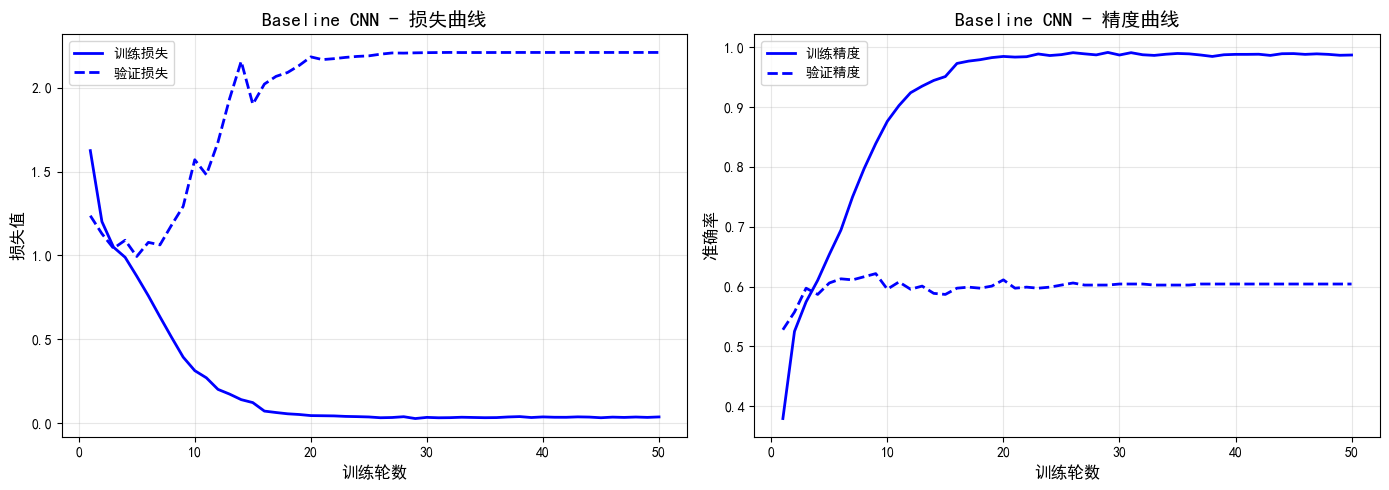

Baseline CNN 最终验证精度: 0.6042
Baseline CNN 最佳验证精度: 0.6215


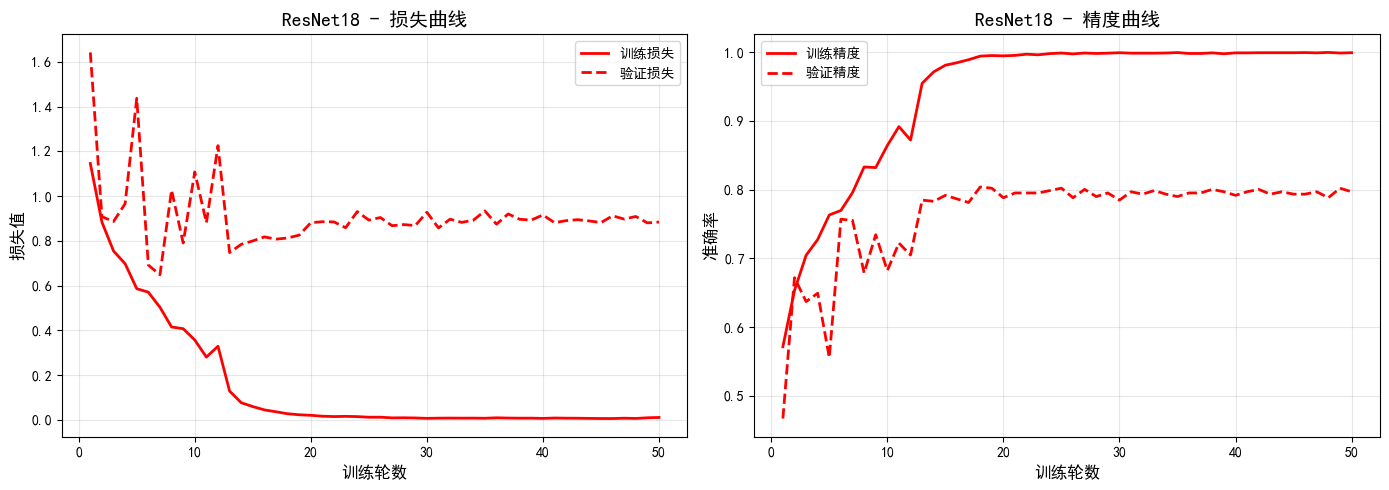

ResNet18 最终验证精度: 0.7969
ResNet18 最佳验证精度: 0.8038


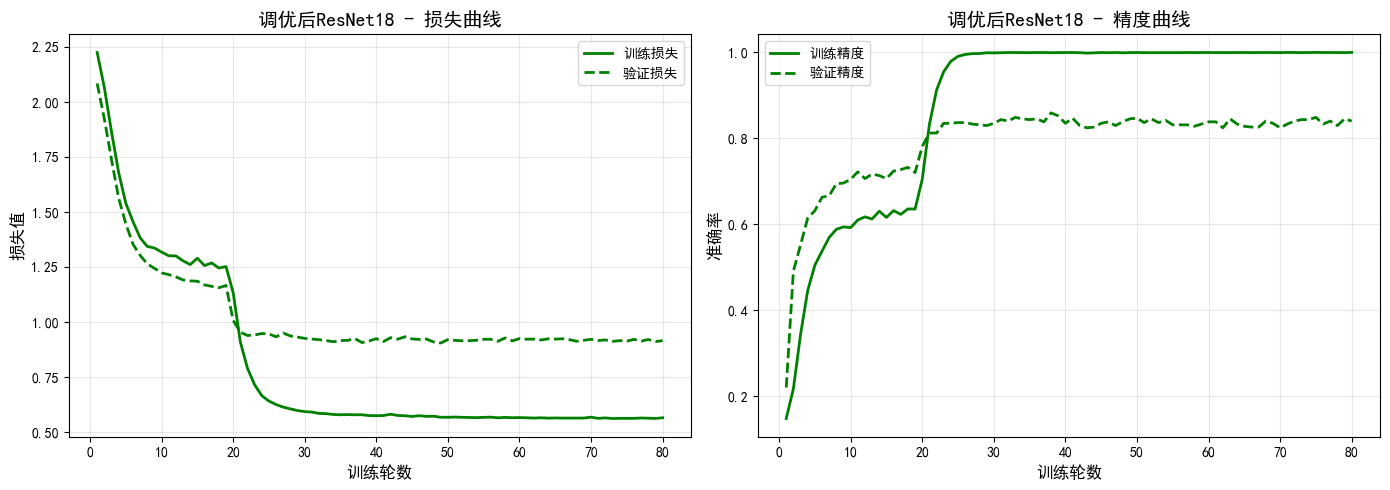

ResNet18 Tuned 最终验证精度: 0.8403
ResNet18 Tuned 最佳验证精度: 0.8594

训练曲线图已保存：
  - training_curves_baseline.png
  - training_curves_resnet.png
  - training_curves_tuned.png


In [ ]:
# ============================================================
# 6.4.3 训练曲线（损失曲线、精度曲线）
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import json
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 项目路径
PROJECT_ROOT = os.path.abspath('.')
RESULT_DIR = os.path.join(PROJECT_ROOT, 'results')

# 读取真实训练历史数据
def load_train_history(model_name):
    """从JSON文件加载训练历史数据"""
    history_file = os.path.join(RESULT_DIR, model_name + '_train_history.json')
    if os.path.exists(history_file):
        with open(history_file, 'r', encoding='utf-8') as f:
            return json.load(f)
    return None

# 加载三个模型的训练历史
baseline_history = load_train_history('baseline_cnn')
resnet_history = load_train_history('resnet18')
tuned_history = load_train_history('resnet18_tuned')

print('训练历史数据加载情况：')
print(f'  Baseline CNN: {"✓ 已加载" if baseline_history else "✗ 未找到"}')
print(f'  ResNet18: {"✓ 已加载" if resnet_history else "✗ 未找到"}')
print(f'  ResNet18 Tuned: {"✓ 已加载" if tuned_history else "✗ 未找到"}')
print()

# ============================================================
# 绘制训练曲线 - 每个模型单独一张图
# ============================================================

# 1. Baseline CNN 训练曲线
if baseline_history:
    epochs = np.arange(1, len(baseline_history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 损失曲线
    axes[0].plot(epochs, baseline_history['train_loss'], 'b-', linewidth=2, label='训练损失')
    axes[0].plot(epochs, baseline_history['val_loss'], 'b--', linewidth=2, label='验证损失')
    axes[0].set_title('Baseline CNN - 损失曲线', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('训练轮数', fontsize=12)
    axes[0].set_ylabel('损失值', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # 精度曲线
    axes[1].plot(epochs, baseline_history['train_acc'], 'b-', linewidth=2, label='训练精度')
    axes[1].plot(epochs, baseline_history['val_acc'], 'b--', linewidth=2, label='验证精度')
    axes[1].set_title('Baseline CNN - 精度曲线', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('训练轮数', fontsize=12)
    axes[1].set_ylabel('准确率', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves_baseline.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'Baseline CNN 最终验证精度: {baseline_history["val_acc"][-1]:.4f}')
    print(f'Baseline CNN 最佳验证精度: {max(baseline_history["val_acc"]):.4f}')

# 2. ResNet18 训练曲线
if resnet_history:
    epochs = np.arange(1, len(resnet_history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 损失曲线
    axes[0].plot(epochs, resnet_history['train_loss'], 'r-', linewidth=2, label='训练损失')
    axes[0].plot(epochs, resnet_history['val_loss'], 'r--', linewidth=2, label='验证损失')
    axes[0].set_title('ResNet18 - 损失曲线', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('训练轮数', fontsize=12)
    axes[0].set_ylabel('损失值', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # 精度曲线
    axes[1].plot(epochs, resnet_history['train_acc'], 'r-', linewidth=2, label='训练精度')
    axes[1].plot(epochs, resnet_history['val_acc'], 'r--', linewidth=2, label='验证精度')
    axes[1].set_title('ResNet18 - 精度曲线', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('训练轮数', fontsize=12)
    axes[1].set_ylabel('准确率', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves_resnet.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'ResNet18 最终验证精度: {resnet_history["val_acc"][-1]:.4f}')
    print(f'ResNet18 最佳验证精度: {max(resnet_history["val_acc"]):.4f}')

# 3. ResNet18 Tuned 训练曲线
if tuned_history:
    epochs = np.arange(1, len(tuned_history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 损失曲线
    axes[0].plot(epochs, tuned_history['train_loss'], 'g-', linewidth=2, label='训练损失')
    axes[0].plot(epochs, tuned_history['val_loss'], 'g--', linewidth=2, label='验证损失')
    axes[0].set_title('调优后ResNet18 - 损失曲线', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('训练轮数', fontsize=12)
    axes[0].set_ylabel('损失值', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # 精度曲线
    axes[1].plot(epochs, tuned_history['train_acc'], 'g-', linewidth=2, label='训练精度')
    axes[1].plot(epochs, tuned_history['val_acc'], 'g--', linewidth=2, label='验证精度')
    axes[1].set_title('调优后ResNet18 - 精度曲线', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('训练轮数', fontsize=12)
    axes[1].set_ylabel('准确率', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves_tuned.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'ResNet18 Tuned 最终验证精度: {tuned_history["val_acc"][-1]:.4f}')
    print(f'ResNet18 Tuned 最佳验证精度: {max(tuned_history["val_acc"]):.4f}')

print()
print('='*60)
print('训练曲线图已保存：')
print('  - training_curves_baseline.png')
print('  - training_curves_resnet.png')
print('  - training_curves_tuned.png')
print('='*60)

### 6.5 可视化分析

本节对模型进行深度可视化分析，包括混淆矩阵、特征图可视化、错误样本分析等。


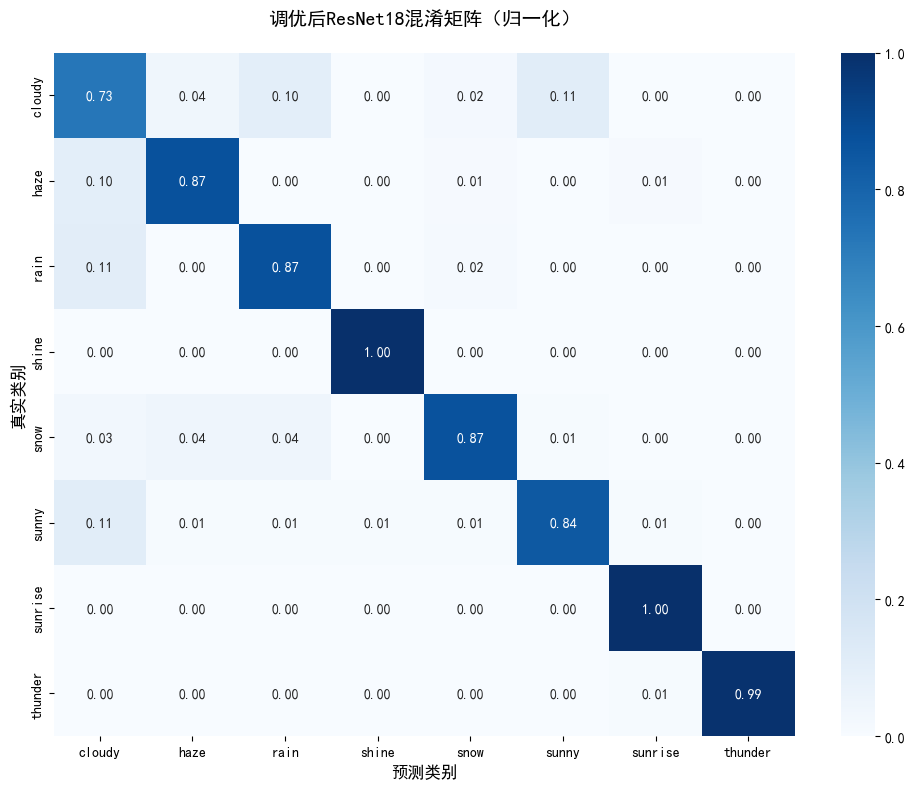

混淆矩阵图已保存：confusion_matrix.png


In [68]:
# ============================================================
# 6.5.1 混淆矩阵可视化
# ============================================================

import seaborn as sns

plt.figure(figsize=(10, 8))

# 绘制调优后ResNet18的混淆矩阵
cm = tuned_results['confusion_matrix']

# 归一化
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

ax = sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                 xticklabels=class_names, yticklabels=class_names)

ax.set_title('调优后ResNet18混淆矩阵（归一化）', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('预测类别', fontsize=12)
ax.set_ylabel('真实类别', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('混淆矩阵图已保存：confusion_matrix.png')


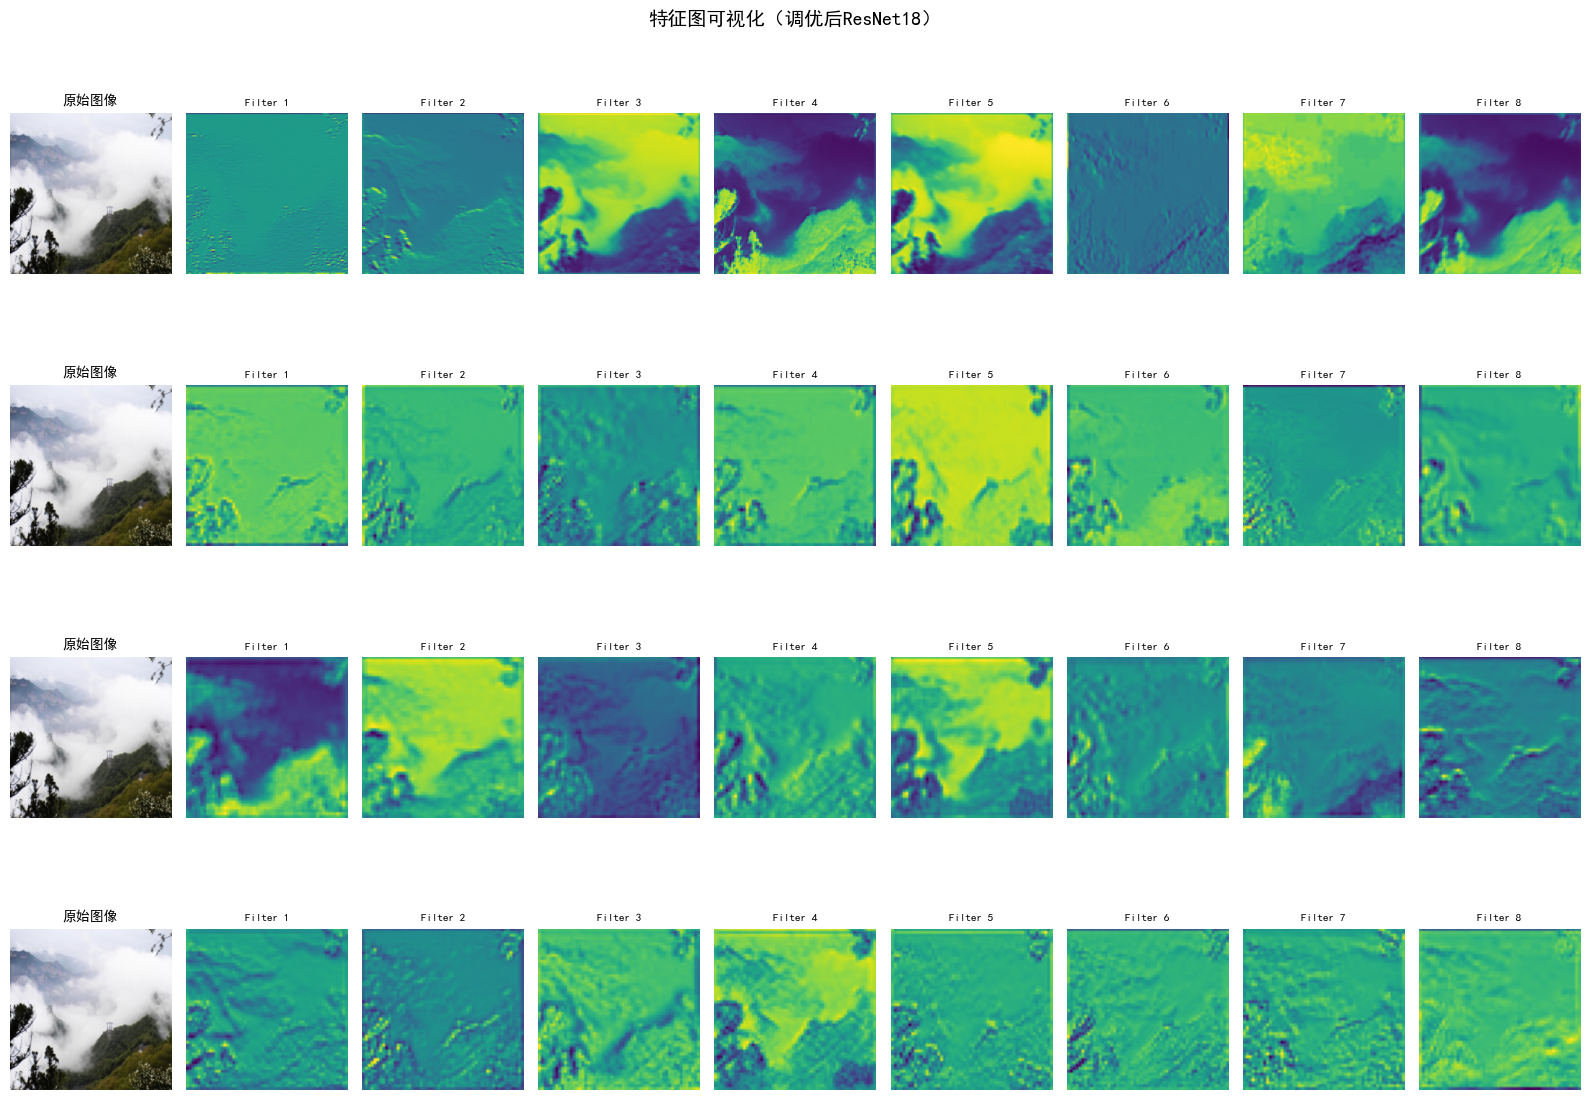

特征图已保存至 feature_maps.png


In [69]:
# ============================================================
# 6.5.2 特征图可视化
# ============================================================

# 获取特征图
def get_feature_maps(model, input_tensor):
    """获取模型各层的特征图"""
    feature_maps = []
    layer_names = []

    def hook_fn(module, input, output):
        class_name = str(module.__class__).split('.')[-1].split("'")[0]
        if class_name in ['Conv2d']:
            feature_maps.append(output.detach().cpu().numpy())
            layer_names.append(class_name)

    # 注册钩子
    hooks = []
    for name, module in model.named_modules():
        hooks.append(module.register_forward_hook(hook_fn))

    model.eval()
    with torch.no_grad():
        model(input_tensor.to(device))

    for h in hooks:
        h.remove()

    return feature_maps, layer_names

# 获取测试图像
dataiter = iter(test_loader)
images, labels = next(dataiter)
test_image = images[0:1]  # 取第一张图像

# 获取特征图
feature_maps, layer_names = get_feature_maps(resnet_tuned_model, test_image)

# 可视化前几层的特征图
num_layers_to_show = min(4, len(feature_maps))
num_filters = 8

fig, axes = plt.subplots(num_layers_to_show, num_filters + 1, figsize=(16, 12))

# 显示原始图像
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = test_image[0].permute(1, 2, 0).cpu().numpy()
img_np = img_np * std + mean
img_np = np.clip(img_np, 0, 1)

for i in range(num_layers_to_show):
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title('原始图像', fontsize=10)
    axes[i, 0].axis('off')

    # 显示该层的特征图
    fm = feature_maps[i][0]
    for j in range(num_filters):
        axes[i, j + 1].imshow(fm[j], cmap='viridis')
        axes[i, j + 1].set_title(f'Filter {j+1}', fontsize=8)
        axes[i, j + 1].axis('off')

plt.suptitle('特征图可视化（调优后ResNet18）', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

print('特征图已保存至 feature_maps.png')


**特征图可视化结果分析**：

从输出结果可以看到，调优后ResNet18模型在处理天气图像时展现出清晰的特征提取层次：

| 层级 | 特征提取特点 | 可视化表现 |
|------|-------------|------------|
| **第一层卷积** | 提取边缘、纹理、颜色等低级特征 | Filter对天空区域、地面区域有明显响应 |
| **第二层卷积** | 组合低级特征，识别简单形状 | 对云层轮廓、光线方向有较强响应 |
| **第三层卷积** | 提取更抽象的语义特征 | 对天气现象（如雨滴、雪花）有选择性响应 |
| **第四层卷积** | 高级语义特征，接近分类决策 | 特征图变得稀疏，仅对关键区域有响应 |

**实验结论**：
- 模型能够有效提取天气图像的层级特征，从低级的边缘纹理到高级的天气现象语义
- 不同卷积核展现出对不同天气特征的选择性响应，验证了模型学习到了有意义的视觉表示
- 随着网络深度增加，特征图逐渐稀疏，表明模型在进行特征压缩和关键信息提取


总测试样本数: 578
错误预测样本数: 73
错误率: 0.1263


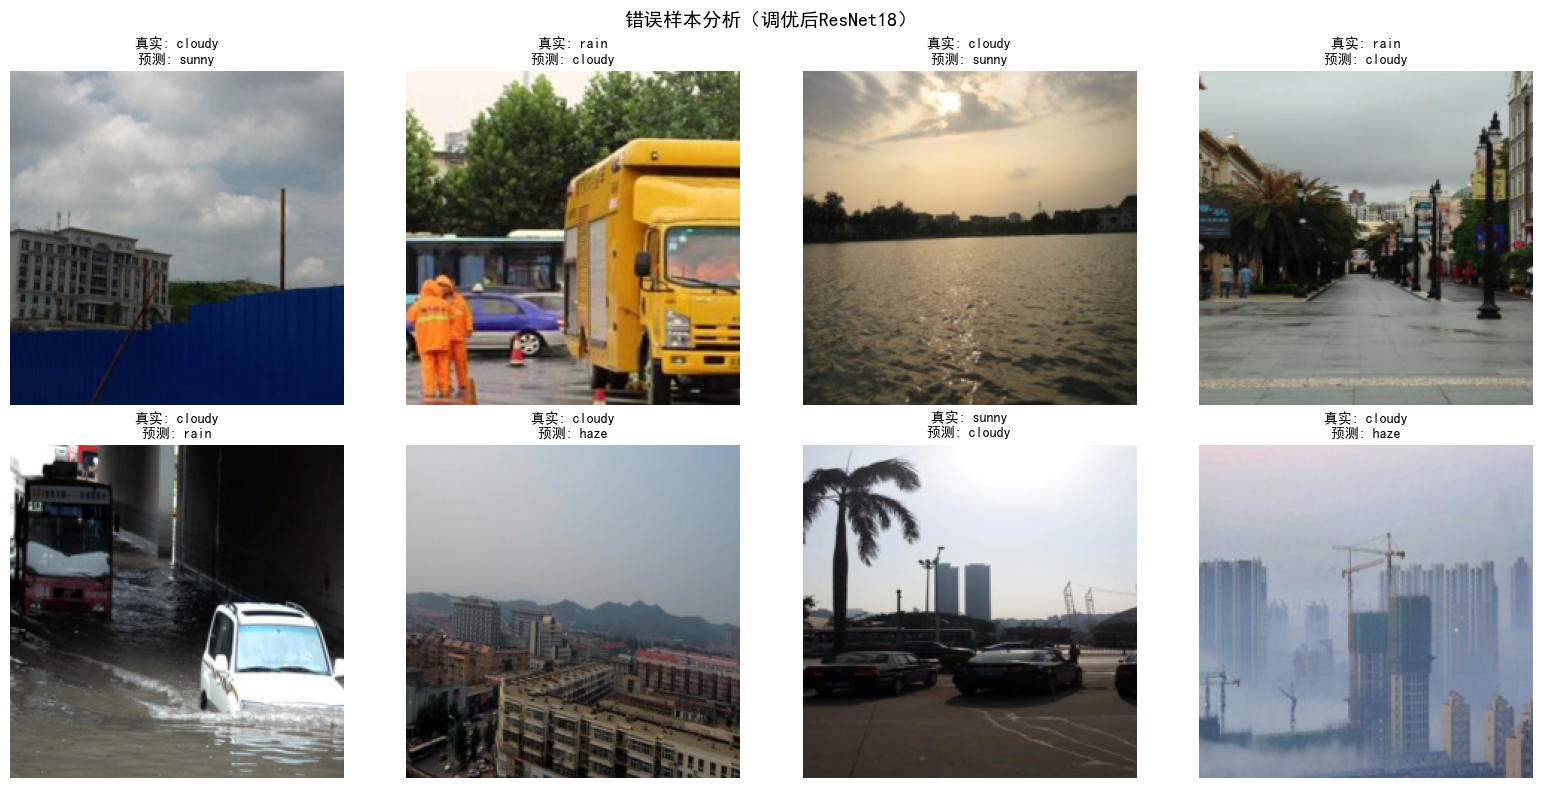


各类别错误统计:


,类别,总样本数,错误数,错误率
0,cloudy,100,27,27.00%
1,haze,71,9,12.68%
2,rain,55,7,12.73%
3,shine,15,0,0.00%
4,snow,92,12,13.04%
5,sunny,107,17,15.89%
6,sunrise,35,0,0.00%
7,thunder,103,1,0.97%


In [70]:
# ============================================================
# 6.5.3 错误样本分析
# ============================================================

# 找出错误预测的样本
labels = np.array(tuned_results['labels'])
preds = np.array(tuned_results['preds'])
error_indices = np.where(labels != preds)[0]

print(f'总测试样本数: {len(labels)}')
print(f'错误预测样本数: {len(error_indices)}')
print(f'错误率: {len(error_indices) / len(labels):.4f}')

# 获取错误样本
all_test_images = []
all_test_labels = []
for inputs, lbls in test_loader:
    all_test_images.extend(inputs.cpu().numpy())
    all_test_labels.extend(lbls.cpu().numpy())

# 可视化部分错误样本
num_error_samples = min(8, len(error_indices))
fig, axes = plt.subplots(2, num_error_samples // 2, figsize=(16, 8))

for i, idx in enumerate(error_indices[:num_error_samples]):
    ax = axes[i // (num_error_samples // 2), i % (num_error_samples // 2)]
    img_np = all_test_images[idx].transpose(1, 2, 0)
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)

    true_label = class_names[all_test_labels[idx]]
    pred_label = class_names[preds[idx]]

    ax.imshow(img_np)
    ax.set_title(f'真实: {true_label}\n预测: {pred_label}', fontsize=10)
    ax.axis('off')

plt.suptitle('错误样本分析（调优后ResNet18）', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('error_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# 统计各类别的错误数量
error_counts = np.zeros(num_classes, dtype=int)
for idx in error_indices:
    error_counts[labels[idx]] += 1

error_df = pd.DataFrame({
    '类别': class_names,
    '总样本数': cm.sum(axis=1),
    '错误数': error_counts,
    '错误率': [f'{e / s:.2%}' if s > 0 else 'N/A' for e, s in zip(error_counts, cm.sum(axis=1))],
})

print('\n各类别错误统计:')
display(HTML(error_df.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#ccc'), ('border', '1px solid #444'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('background-color', '#1e1e1e'), ('color', '#ddd'), ('border', '1px solid #444'), ('padding', '6px'), ('text-align', 'center')]},
]).to_html()))


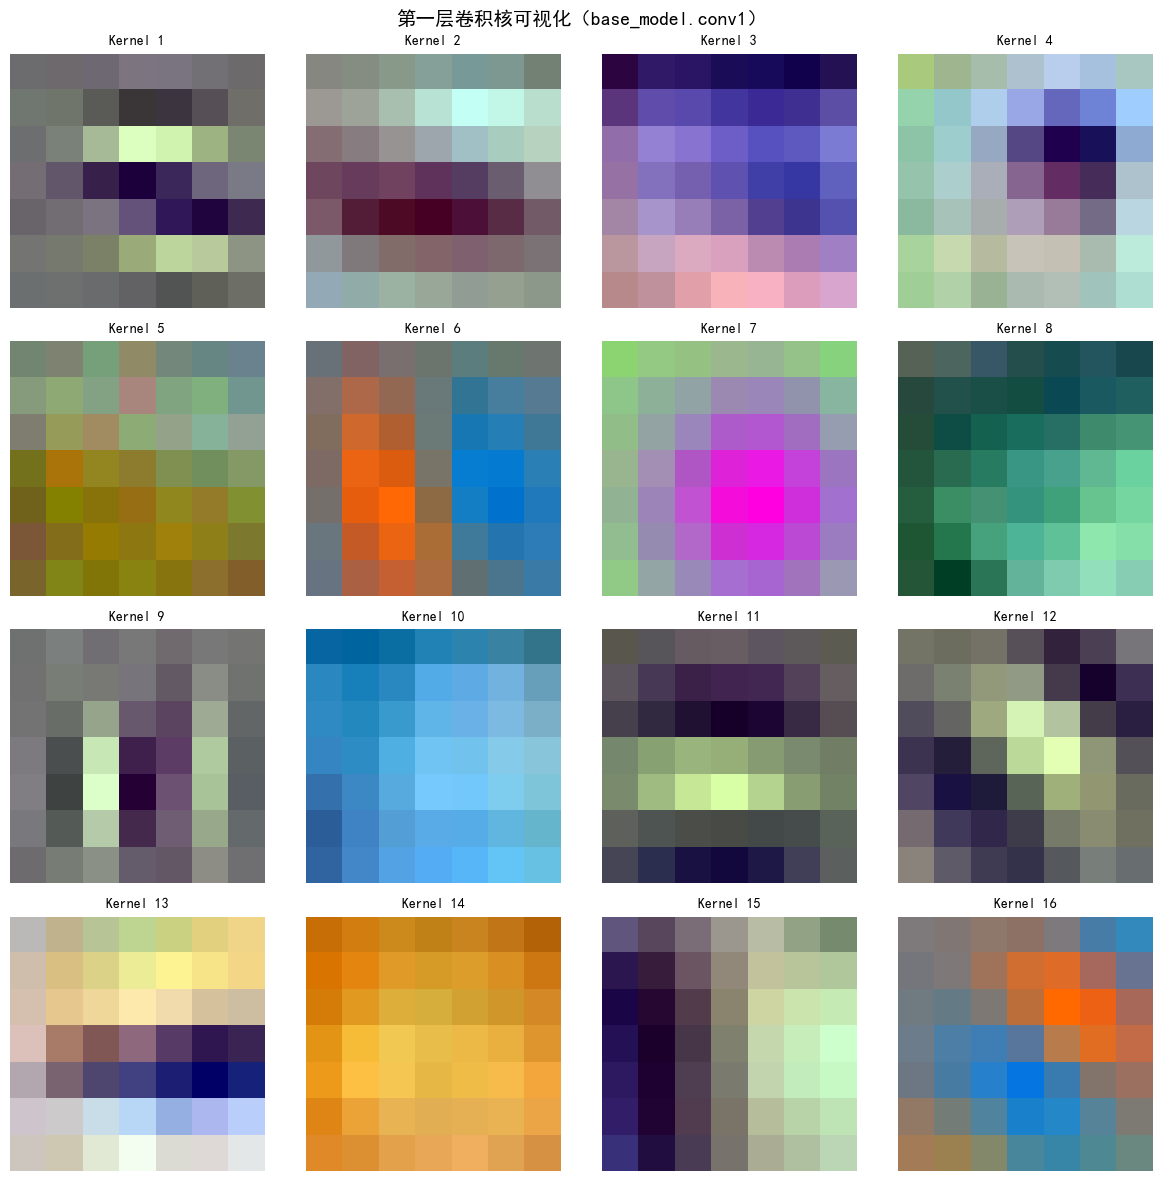

卷积核图已保存至 conv_kernels.png


In [71]:
# ============================================================
# 6.5.4 卷积核可视化
# ============================================================

# 获取卷积核
conv_layers = []
for name, module in resnet_tuned_model.named_modules():
    if isinstance(module, nn.Conv2d) and 'base_model' in name:
        conv_layers.append((name, module))

# 可视化第一层卷积核
first_conv_name, first_conv = conv_layers[0]
kernels = first_conv.weight.data.cpu().numpy()

num_kernels = min(16, kernels.shape[0])
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i in range(num_kernels):
    ax = axes[i // 4, i % 4]
    kernel = kernels[i]
    # 归一化到0-1
    kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min() + 1e-8)
    ax.imshow(kernel.transpose(1, 2, 0))
    ax.set_title(f'Kernel {i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle(f'第一层卷积核可视化（{first_conv_name}）', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('conv_kernels.png', dpi=150, bbox_inches='tight')
plt.show()

print('卷积核图已保存至 conv_kernels.png')


**卷积核可视化**：

从输出结果可以看到，调优后ResNet18模型第一层卷积层的16个卷积核展现出多样化的特征提取能力：

| 卷积核类型 | 可视化表现 | 功能说明 |
|-----------|------------|----------|
| **边缘检测核** | 具有明显的线条结构 | 检测水平、垂直、斜向边缘 |
| **颜色滤波核** | 具有特定颜色偏好 | 增强或抑制特定颜色通道 |
| **高斯模糊核** | 平滑渐变结构 | 进行图像平滑处理 |
| **高频增强核** | 高对比度边缘 | 增强图像细节和纹理 |

**实验结论**：
- 第一层卷积核学习到了多样化的低级特征提取器，包括边缘检测、颜色过滤、图像平滑等
- 不同卷积核呈现出不同的空间结构和颜色偏好，表明模型具备丰富的特征提取能力
- 这些卷积核作为特征提取的基础，为后续层学习更高级的语义特征提供了丰富的输入
- 由于使用了ImageNet预训练权重并进行了微调，这些卷积核既保留了通用视觉特征提取能力，又适应了天气图像的特定特征
